# Part 9 (Andrew's Version)

This notebook implements three **advanced-feature hypotheses** and trains one high-value model per hypothesis.
Each section follows the same structure: **hypothesis -> feature build -> model fit -> betting metrics -> conclusion**.

## Train/Test Period Used (Out-of-Sample Focus)

- **Training period (in-sample):** all games with `season_end < 2025` (historical seasons before the 2024/25 test season)
- **Testing period (out-of-sample):** all games with `season_end == 2025` (the 2024/25 season in this merged dataset)
- **Evaluation for Part 9 conclusions:** use the **test-set metrics** only (`RMSE`, betting accuracy, ROI, threshold sweep)
- **Hyperparameter tuning:** performed on the training set only using **time-series cross-validation**

This keeps the Part 9 comparisons aligned with the prior project workflow (train on past seasons, evaluate on a held-out future season).


## Run Order

1. Run setup and data pipeline cells first.
2. Run each hypothesis section independently.
3. Use the final comparison table to decide which direction to carry into the final report.


In [44]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42
TEST_SEASON_END = 2025
ODDS = -110

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

print('Setup complete.')


Setup complete.


In [45]:
# Team code normalization maps used in the main project
TEAM_MAP_BETTING = {
    'gs': 'GSW',
    'no': 'NOP',
    'ny': 'NYK',
    'sa': 'SAS',
    'utah': 'UTA',
    'wsh': 'WAS',
}
TEAM_MAP_HISTORICAL = {
    'NJN': 'BKN',
    'NOH': 'NOP',
    'NOK': 'NOP',
    'NOJ': 'NOP',
    'SEA': 'OKC',
    'CHN': 'CHA',
    'CHH': 'CHA',
    'VAN': 'MEM',
}


def standardize_team(abbr, source='betting'):
    if pd.isna(abbr):
        return abbr
    a = str(abbr).strip()
    if source == 'betting':
        return TEAM_MAP_BETTING.get(a.lower(), a.upper())
    if source == 'historical':
        return TEAM_MAP_HISTORICAL.get(a.upper(), a.upper())
    return a.upper()


def season_end_year(dates):
    return dates.dt.year + (dates.dt.month >= 7)


def load_betting_data(path='Data/Betting Data/nba_2008-2025.csv'):
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.normalize()
    df = df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)

    df['home'] = df['home'].map(lambda x: standardize_team(x, 'betting'))
    df['away'] = df['away'].map(lambda x: standardize_team(x, 'betting'))

    numeric_cols = [
        'spread', 'total', 'moneyline_home', 'moneyline_away',
        'h2_spread', 'h2_total', 'id_spread', 'id_total',
        'score_home', 'score_away',
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df['actual_total'] = df['score_home'] + df['score_away']
    df['season_end'] = season_end_year(df['date'])
    df['season_label'] = (df['season_end'] - 1).astype(int).astype(str) + '/' + df['season_end'].astype(int).astype(str).str[-2:]
    return df


def api_team_logs_to_games(api_df):
    if api_df.empty:
        return pd.DataFrame()

    df = api_df.copy()
    df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'], errors='coerce').dt.normalize()
    df = df.dropna(subset=['GAME_DATE'])
    df['is_home'] = df['MATCHUP'].str.contains(r'vs\.', regex=True, na=False).astype(int)

    home = df[df['is_home'] == 1].copy()
    away = df[df['is_home'] == 0].copy()
    merged = home.merge(away, on='GAME_ID', suffixes=('_home', '_away'))

    out = pd.DataFrame({
        'game_date': merged['GAME_DATE_home'],
        'season_type': 'Regular Season',
        'home_team': merged['TEAM_ABBREVIATION_home'].str.upper(),
        'away_team': merged['TEAM_ABBREVIATION_away'].str.upper(),
        'pts_home': pd.to_numeric(merged['PTS_home'], errors='coerce'),
        'pts_away': pd.to_numeric(merged['PTS_away'], errors='coerce'),
        'fga_home': pd.to_numeric(merged['FGA_home'], errors='coerce'),
        'fga_away': pd.to_numeric(merged['FGA_away'], errors='coerce'),
        'fta_home': pd.to_numeric(merged['FTA_home'], errors='coerce'),
        'fta_away': pd.to_numeric(merged['FTA_away'], errors='coerce'),
        'oreb_home': pd.to_numeric(merged['OREB_home'], errors='coerce'),
        'oreb_away': pd.to_numeric(merged['OREB_away'], errors='coerce'),
        'tov_home': pd.to_numeric(merged['TOV_home'], errors='coerce'),
        'tov_away': pd.to_numeric(merged['TOV_away'], errors='coerce'),
        'fg_pct_home': pd.to_numeric(merged['FG_PCT_home'], errors='coerce'),
        'fg_pct_away': pd.to_numeric(merged['FG_PCT_away'], errors='coerce'),
        'fg3_pct_home': pd.to_numeric(merged['FG3_PCT_home'], errors='coerce'),
        'fg3_pct_away': pd.to_numeric(merged['FG3_PCT_away'], errors='coerce'),
        'ft_pct_home': pd.to_numeric(merged['FT_PCT_home'], errors='coerce'),
        'ft_pct_away': pd.to_numeric(merged['FT_PCT_away'], errors='coerce'),
        'reb_home': pd.to_numeric(merged['REB_home'], errors='coerce'),
        'reb_away': pd.to_numeric(merged['REB_away'], errors='coerce'),
        'ast_home': pd.to_numeric(merged['AST_home'], errors='coerce'),
        'ast_away': pd.to_numeric(merged['AST_away'], errors='coerce'),
        'stl_home': pd.to_numeric(merged['STL_home'], errors='coerce'),
        'stl_away': pd.to_numeric(merged['STL_away'], errors='coerce'),
        'blk_home': pd.to_numeric(merged['BLK_home'], errors='coerce'),
        'blk_away': pd.to_numeric(merged['BLK_away'], errors='coerce'),
    })
    return out


def load_game_data(path_hist='Data/Game Data/game.csv', path_api='Data/Game Data/game_2024_2025.csv'):
    hist = pd.read_csv(path_hist)
    hist['game_date'] = pd.to_datetime(hist['game_date'], errors='coerce').dt.normalize()
    hist = hist.dropna(subset=['game_date'])

    season_year = pd.to_numeric(hist['season_id'].astype(str).str[1:], errors='coerce')
    hist = hist[(season_year >= 2007) & (hist['season_type'].isin(['Regular Season', 'Playoffs']))].copy()

    hist['team_abbreviation_home'] = hist['team_abbreviation_home'].map(lambda x: standardize_team(x, 'historical'))
    hist['team_abbreviation_away'] = hist['team_abbreviation_away'].map(lambda x: standardize_team(x, 'historical'))

    hist_out = pd.DataFrame({
        'game_date': hist['game_date'],
        'season_type': hist['season_type'],
        'home_team': hist['team_abbreviation_home'],
        'away_team': hist['team_abbreviation_away'],
        'pts_home': pd.to_numeric(hist['pts_home'], errors='coerce'),
        'pts_away': pd.to_numeric(hist['pts_away'], errors='coerce'),
        'fga_home': pd.to_numeric(hist['fga_home'], errors='coerce'),
        'fga_away': pd.to_numeric(hist['fga_away'], errors='coerce'),
        'fta_home': pd.to_numeric(hist['fta_home'], errors='coerce'),
        'fta_away': pd.to_numeric(hist['fta_away'], errors='coerce'),
        'oreb_home': pd.to_numeric(hist['oreb_home'], errors='coerce'),
        'oreb_away': pd.to_numeric(hist['oreb_away'], errors='coerce'),
        'tov_home': pd.to_numeric(hist['tov_home'], errors='coerce'),
        'tov_away': pd.to_numeric(hist['tov_away'], errors='coerce'),
        'fg_pct_home': pd.to_numeric(hist['fg_pct_home'], errors='coerce'),
        'fg_pct_away': pd.to_numeric(hist['fg_pct_away'], errors='coerce'),
        'fg3_pct_home': pd.to_numeric(hist['fg3_pct_home'], errors='coerce'),
        'fg3_pct_away': pd.to_numeric(hist['fg3_pct_away'], errors='coerce'),
        'ft_pct_home': pd.to_numeric(hist['ft_pct_home'], errors='coerce'),
        'ft_pct_away': pd.to_numeric(hist['ft_pct_away'], errors='coerce'),
        'reb_home': pd.to_numeric(hist['reb_home'], errors='coerce'),
        'reb_away': pd.to_numeric(hist['reb_away'], errors='coerce'),
        'ast_home': pd.to_numeric(hist['ast_home'], errors='coerce'),
        'ast_away': pd.to_numeric(hist['ast_away'], errors='coerce'),
        'stl_home': pd.to_numeric(hist['stl_home'], errors='coerce'),
        'stl_away': pd.to_numeric(hist['stl_away'], errors='coerce'),
        'blk_home': pd.to_numeric(hist['blk_home'], errors='coerce'),
        'blk_away': pd.to_numeric(hist['blk_away'], errors='coerce'),
    })

    api_out = pd.DataFrame()
    if pd.io.common.file_exists(path_api):
        api_raw = pd.read_csv(path_api)
        api_out = api_team_logs_to_games(api_raw)

    all_games = pd.concat([hist_out, api_out], ignore_index=True)
    all_games['season_end'] = season_end_year(pd.to_datetime(all_games['game_date']))
    all_games['game_key'] = (
        pd.to_datetime(all_games['game_date']).dt.strftime('%Y%m%d')
        + '_' + all_games['home_team'].astype(str)
        + '_' + all_games['away_team'].astype(str)
    )
    all_games = all_games.sort_values('game_date').drop_duplicates('game_key').drop(columns=['game_key'])
    all_games = all_games.reset_index(drop=True)
    return all_games


betting_df = load_betting_data()
game_df = load_game_data()

print(f'Betting rows: {len(betting_df):,} | {betting_df.date.min().date()} -> {betting_df.date.max().date()}')
print(f'Game rows:    {len(game_df):,} | {game_df.game_date.min().date()} -> {game_df.game_date.max().date()}')


Betting rows: 23,118 | 2007-10-30 -> 2025-06-22
Game rows:    21,851 | 2007-10-30 -> 2025-06-22


In [46]:
def american_to_prob(odds):
    x = pd.to_numeric(odds, errors='coerce')
    out = pd.Series(np.nan, index=x.index)
    pos = x > 0
    neg = x < 0
    out.loc[pos] = 100.0 / (x.loc[pos] + 100.0)
    out.loc[neg] = (-x.loc[neg]) / ((-x.loc[neg]) + 100.0)
    return out


def build_team_long(game_data):
    home = game_data[[
        'game_date', 'season_end', 'home_team', 'away_team',
        'pts_home', 'pts_away', 'fga_home', 'fta_home', 'oreb_home', 'tov_home',
        'fga_away', 'fta_away', 'oreb_away', 'tov_away',
        'fg_pct_home', 'fg3_pct_home', 'ft_pct_home', 'reb_home', 'ast_home', 'stl_home', 'blk_home'
    ]].copy()
    home.columns = [
        'date', 'season_end', 'team', 'opponent',
        'pts_scored', 'pts_allowed', 'fga', 'fta', 'oreb', 'tov',
        'opp_fga', 'opp_fta', 'opp_oreb', 'opp_tov',
        'fg_pct', 'fg3_pct', 'ft_pct', 'reb', 'ast', 'stl', 'blk'
    ]
    home['is_home'] = 1

    away = game_data[[
        'game_date', 'season_end', 'away_team', 'home_team',
        'pts_away', 'pts_home', 'fga_away', 'fta_away', 'oreb_away', 'tov_away',
        'fga_home', 'fta_home', 'oreb_home', 'tov_home',
        'fg_pct_away', 'fg3_pct_away', 'ft_pct_away', 'reb_away', 'ast_away', 'stl_away', 'blk_away'
    ]].copy()
    away.columns = [
        'date', 'season_end', 'team', 'opponent',
        'pts_scored', 'pts_allowed', 'fga', 'fta', 'oreb', 'tov',
        'opp_fga', 'opp_fta', 'opp_oreb', 'opp_tov',
        'fg_pct', 'fg3_pct', 'ft_pct', 'reb', 'ast', 'stl', 'blk'
    ]
    away['is_home'] = 0

    tg = pd.concat([home, away], ignore_index=True)
    tg = tg.sort_values(['team', 'season_end', 'date']).reset_index(drop=True)

    tg['poss_for'] = tg['fga'] - tg['oreb'] + tg['tov'] + 0.44 * tg['fta']
    tg['poss_against'] = tg['opp_fga'] - tg['opp_oreb'] + tg['opp_tov'] + 0.44 * tg['opp_fta']
    tg['pace'] = (tg['poss_for'] + tg['poss_against']) / 2.0

    tg['off_rtg'] = 100.0 * tg['pts_scored'] / tg['poss_for'].replace(0, np.nan)
    tg['def_rtg'] = 100.0 * tg['pts_allowed'] / tg['poss_against'].replace(0, np.nan)
    tg['net_rtg'] = tg['off_rtg'] - tg['def_rtg']

    ts_denom = 2.0 * (tg['fga'] + 0.44 * tg['fta'])
    tg['ts_pct'] = tg['pts_scored'] / ts_denom.replace(0, np.nan)

    return tg


def add_schedule_features(team_games):
    out = []
    for (team, season_end), g in team_games.groupby(['team', 'season_end']):
        g = g.sort_values('date').copy()

        g['days_rest'] = g['date'].diff().dt.days
        g['days_rest'] = g['days_rest'].fillna(7).clip(lower=0)
        g['is_b2b'] = (g['days_rest'] <= 1).astype(int)

        g_idx = g.set_index('date')
        g['_one'] = 1.0
        g_idx = g.set_index('date')
        g['games_last_4d'] = g_idx['_one'].rolling('4D').sum().shift(1).fillna(0).values
        g['games_last_7d'] = g_idx['_one'].rolling('7D').sum().shift(1).fillna(0).values
        g = g.drop(columns=['_one'])

        away_streak = []
        home_streak = []
        a_count = 0
        h_count = 0
        prev_home = g['is_home'].shift(1)
        for val in prev_home:
            if pd.isna(val):
                a_count = 0
                h_count = 0
            elif int(val) == 0:
                a_count += 1
                h_count = 0
            else:
                h_count += 1
                a_count = 0
            away_streak.append(a_count)
            home_streak.append(h_count)

        g['away_streak_in'] = away_streak
        g['home_streak_in'] = home_streak
        out.append(g)

    return pd.concat(out, ignore_index=True)


def add_rolling_features(team_games, windows=(5, 10)):
    metric_cols = [
        'pts_scored', 'pts_allowed', 'pace', 'off_rtg', 'def_rtg', 'net_rtg',
        'ts_pct', 'fg_pct', 'fg3_pct', 'ft_pct', 'reb', 'ast', 'stl', 'blk',
        'days_rest', 'is_b2b', 'games_last_4d', 'games_last_7d',
        'away_streak_in', 'home_streak_in',
    ]

    out = []
    for (team, season_end), g in team_games.groupby(['team', 'season_end']):
        g = g.sort_values('date').copy()
        for w in windows:
            for col in metric_cols:
                g[f'{col}_L{w}'] = g[col].shift(1).rolling(w, min_periods=1).mean()
        out.append(g)

    return pd.concat(out, ignore_index=True)


def build_feature_matrix(betting_df, game_df, windows=(5, 10)):
    team_games = build_team_long(game_df)
    team_games = add_schedule_features(team_games)
    team_games = add_rolling_features(team_games, windows=windows)

    keep_cols = [
        'date', 'team',
        'days_rest', 'is_b2b', 'games_last_4d', 'games_last_7d', 'away_streak_in', 'home_streak_in'
    ]
    for w in windows:
        keep_cols.extend([
            f'pts_scored_L{w}', f'pts_allowed_L{w}', f'pace_L{w}',
            f'off_rtg_L{w}', f'def_rtg_L{w}', f'net_rtg_L{w}',
            f'ts_pct_L{w}', f'days_rest_L{w}', f'is_b2b_L{w}',
            f'games_last_7d_L{w}'
        ])

    keep_cols = [c for c in keep_cols if c in team_games.columns]
    team_features = team_games[keep_cols].copy()

    features = betting_df.copy()
    features['home_std'] = features['home'].map(lambda x: standardize_team(x, 'betting'))
    features['away_std'] = features['away'].map(lambda x: standardize_team(x, 'betting'))

    home_tbl = team_features.rename(columns={'date': 'date', 'team': 'home_std'})
    home_tbl = home_tbl.rename(columns={c: f'H_{c}' for c in home_tbl.columns if c not in ['date', 'home_std']})

    away_tbl = team_features.rename(columns={'date': 'date', 'team': 'away_std'})
    away_tbl = away_tbl.rename(columns={c: f'A_{c}' for c in away_tbl.columns if c not in ['date', 'away_std']})

    features = features.merge(home_tbl, on=['date', 'home_std'], how='left')
    features = features.merge(away_tbl, on=['date', 'away_std'], how='left')

    features['vegas_total'] = pd.to_numeric(features['total'], errors='coerce')
    features['vegas_spread'] = pd.to_numeric(features['spread'], errors='coerce')

    for w in windows:
        h_pts = f'H_pts_scored_L{w}'
        a_pts = f'A_pts_scored_L{w}'
        h_all = f'H_pts_allowed_L{w}'
        a_all = f'A_pts_allowed_L{w}'
        h_pace = f'H_pace_L{w}'
        a_pace = f'A_pace_L{w}'
        h_off = f'H_off_rtg_L{w}'
        a_off = f'A_off_rtg_L{w}'
        h_def = f'H_def_rtg_L{w}'
        a_def = f'A_def_rtg_L{w}'
        h_ts = f'H_ts_pct_L{w}'
        a_ts = f'A_ts_pct_L{w}'
        h_net = f'H_net_rtg_L{w}'
        a_net = f'A_net_rtg_L{w}'

        if all(col in features.columns for col in [h_pts, a_pts]):
            features[f'combined_pts_L{w}'] = features[h_pts] + features[a_pts]
        if all(col in features.columns for col in [h_all, a_all]):
            features[f'combined_allowed_L{w}'] = features[h_all] + features[a_all]
            features[f'expected_total_L{w}'] = (features[h_pts] + features[a_pts] + features[h_all] + features[a_all]) / 2.0
        if all(col in features.columns for col in [h_pace, a_pace]):
            features[f'pace_sum_L{w}'] = features[h_pace] + features[a_pace]
        if all(col in features.columns for col in [h_off, a_off, h_def, a_def]):
            features[f'off_vs_def_gap_L{w}'] = (features[h_off] - features[a_def]) + (features[a_off] - features[h_def])
        if all(col in features.columns for col in [h_ts, a_ts]):
            features[f'ts_diff_L{w}'] = features[h_ts] - features[a_ts]
        if all(col in features.columns for col in [h_net, a_net]):
            features[f'net_rtg_diff_L{w}'] = features[h_net] - features[a_net]

    if all(c in features.columns for c in ['H_days_rest', 'A_days_rest']):
        features['rest_diff'] = features['H_days_rest'] - features['A_days_rest']
    if all(c in features.columns for c in ['H_is_b2b', 'A_is_b2b']):
        features['b2b_diff'] = features['H_is_b2b'] - features['A_is_b2b']
    if all(c in features.columns for c in ['H_games_last_7d', 'A_games_last_7d']):
        features['schedule_load_diff'] = features['H_games_last_7d'] - features['A_games_last_7d']
    if all(c in features.columns for c in ['H_away_streak_in', 'A_away_streak_in']):
        features['away_trip_diff'] = features['H_away_streak_in'] - features['A_away_streak_in']

    features['moneyline_home'] = pd.to_numeric(features['moneyline_home'], errors='coerce')
    features['moneyline_away'] = pd.to_numeric(features['moneyline_away'], errors='coerce')
    features['h2_total'] = pd.to_numeric(features['h2_total'], errors='coerce')
    features['h2_spread'] = pd.to_numeric(features['h2_spread'], errors='coerce')
    features['id_total'] = pd.to_numeric(features['id_total'], errors='coerce')
    features['id_spread'] = pd.to_numeric(features['id_spread'], errors='coerce')

    features['ml_home_prob_raw'] = american_to_prob(features['moneyline_home'])
    features['ml_away_prob_raw'] = american_to_prob(features['moneyline_away'])
    prob_sum = features['ml_home_prob_raw'] + features['ml_away_prob_raw']
    features['ml_home_prob_nv'] = features['ml_home_prob_raw'] / prob_sum
    features['ml_away_prob_nv'] = features['ml_away_prob_raw'] / prob_sum
    features['ml_favorite_prob'] = np.nanmax(np.vstack([features['ml_home_prob_nv'], features['ml_away_prob_nv']]), axis=0)
    features['ml_edge_home'] = features['ml_home_prob_nv'] - features['ml_away_prob_nv']

    features['spread_abs'] = features['vegas_spread'].abs()
    features['half_total_implied'] = 2.0 * features['h2_total']
    features['half_total_gap'] = features['vegas_total'] - features['half_total_implied']
    features['spread_half_gap'] = features['vegas_spread'] - features['h2_spread']
    features['missing_moneyline'] = features[['moneyline_home', 'moneyline_away']].isna().any(axis=1).astype(int)
    features['missing_half_line'] = features[['h2_total', 'h2_spread']].isna().any(axis=1).astype(int)

    required_history = ['H_pts_scored_L5', 'A_pts_scored_L5', 'H_pts_allowed_L5', 'A_pts_allowed_L5']
    required_history = [c for c in required_history if c in features.columns]

    before = len(features)
    if required_history:
        features = features.dropna(subset=required_history)

    features = features.drop(columns=['home_std', 'away_std'], errors='ignore')

    # Remove post-game scoreboard columns so they cannot be used as predictors.
    post_game_cols = [c for c in features.columns if c.startswith(('score_', 'q1_', 'q2_', 'q3_', 'q4_', 'ot_'))]
    post_game_cols += [c for c in ['over_hit'] if c in features.columns]
    if post_game_cols:
        features = features.drop(columns=post_game_cols, errors='ignore')

    # Remove in-game / second-half betting fields and their derivatives (pregame leakage risk).
    in_game_market_cols = [
        c for c in [
            'h2_total', 'h2_spread', 'id_total', 'id_spread',
            'half_total_implied', 'half_total_gap', 'spread_half_gap', 'missing_half_line'
        ] if c in features.columns
    ]
    if in_game_market_cols:
        features = features.drop(columns=in_game_market_cols, errors='ignore')

    features = features.sort_values('date').reset_index(drop=True)
    print(f'Feature matrix: {len(features):,} rows (dropped {before - len(features):,} rows with no rolling history)')

    return features


def compute_metrics(y_true, y_pred, vegas_line, odds=-110):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    vegas = np.asarray(vegas_line)

    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    correct = (y_pred > vegas) == (y_true > vegas)
    accuracy = float(np.mean(correct))

    lose_amt = abs(odds) / 100.0
    roi = float((np.sum(correct) - np.sum(~correct) * lose_amt) / len(correct) * 100.0)
    return {
        'rmse': rmse,
        'accuracy': accuracy,
        'roi_all_bets': roi,
        'n_bets': int(len(correct)),
    }


def threshold_sweep(y_true, y_pred, vegas_line, thresholds=range(1, 11), odds=-110):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    vegas = np.asarray(vegas_line)

    gap = np.abs(y_pred - vegas)
    correct = (y_pred > vegas) == (y_true > vegas)
    lose_amt = abs(odds) / 100.0

    rows = []
    for t in thresholds:
        m = gap > t
        n = int(m.sum())
        if n == 0:
            rows.append({'threshold': t, 'n_bets': 0, 'accuracy': np.nan, 'roi': np.nan})
            continue
        acc = float(np.mean(correct[m]))
        roi = float((np.sum(correct[m]) - np.sum(~correct[m]) * lose_amt) / n * 100.0)
        rows.append({'threshold': t, 'n_bets': n, 'accuracy': acc, 'roi': roi})

    return pd.DataFrame(rows)


def run_experiment(features_df, feature_cols, estimator, param_grid, label, test_season_end=TEST_SEASON_END):
    # De-duplicate columns so vegas_total stays 1-D even if included in feature_cols.
    base_cols = ['date', 'season_end', 'actual_total', 'vegas_total']
    feature_cols = list(dict.fromkeys(feature_cols))
    cols = list(dict.fromkeys(base_cols + feature_cols))

    data = features_df[cols].copy()
    data = data.dropna(subset=['season_end', 'actual_total', 'vegas_total'])
    data = data.sort_values('date')

    train = data[data['season_end'] != test_season_end].copy()
    test = data[data['season_end'] == test_season_end].copy()

    X_train = train[feature_cols]
    y_train = train['actual_total']
    X_test = test[feature_cols]
    y_test = test['actual_total']

    vegas_test = test['vegas_total']
    # Defensive guard: if vegas_total ever comes through as duplicate columns, collapse to first.
    if isinstance(vegas_test, pd.DataFrame):
        vegas_test = vegas_test.iloc[:, 0]

    tscv = TimeSeriesSplit(n_splits=5)
    search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=tscv,
        n_jobs=-1,
    )
    search.fit(X_train, y_train)

    pred = search.best_estimator_.predict(X_test)
    base = compute_metrics(y_test, pred, vegas_test, odds=ODDS)
    sweep = threshold_sweep(y_test, pred, vegas_test, odds=ODDS)

    viable = sweep[sweep['n_bets'] >= 30].dropna(subset=['roi'])
    if len(viable) > 0:
        best_row = viable.loc[viable['roi'].idxmax()].to_dict()
    else:
        best_row = {'threshold': np.nan, 'n_bets': 0, 'accuracy': np.nan, 'roi': np.nan}

    result = {
        'label': label,
        'features_used': feature_cols,
        'best_params': search.best_params_,
        'base_metrics': base,
        'threshold_table': sweep,
        'best_threshold_row': best_row,
        'test_rows': len(test),
    }

    print('=' * 90)
    print(label)
    print('=' * 90)
    print(f"Train rows: {len(train):,} | Test rows: {len(test):,}")
    print('Best params:', search.best_params_)
    print(f"RMSE={base['rmse']:.3f} | Accuracy={base['accuracy']:.3%} | ROI(all bets)={base['roi_all_bets']:.2f}%")
    if pd.notna(best_row['threshold']):
        print(
            f"Best threshold (>=30 bets): t>{int(best_row['threshold'])} | "
            f"bets={int(best_row['n_bets'])} | acc={best_row['accuracy']:.3%} | roi={best_row['roi']:.2f}%"
        )
    else:
        print('No threshold met the >=30 bets rule.')

    return result



FORBIDDEN_FEATURE_COLUMNS = {
    'score_home',
    'score_away',
    'pts_home',
    'pts_away',
    'over_hit',
    # In-game / outcome-coded betting fields (leakage for a pregame full-game totals model)
    'id_total',
    'id_spread',
    'half_total_implied',
    'half_total_gap',
    'spread_half_gap',
    'missing_half_line',
}
FORBIDDEN_PREFIXES = ('q1_', 'q2_', 'q3_', 'q4_', 'ot_', 'h2_', 'id_')


def validate_feature_set(feature_cols, name='feature_set'):
    bad_exact = sorted(set(feature_cols) & FORBIDDEN_FEATURE_COLUMNS)
    bad_prefix = sorted([c for c in feature_cols if c.lower().startswith(FORBIDDEN_PREFIXES)])
    bad_target = ['actual_total'] if 'actual_total' in feature_cols else []
    bad = bad_exact + bad_prefix + bad_target
    if bad:
        raise ValueError(f"{name} contains target/post-game leakage columns: {sorted(set(bad))}")


features_df = build_feature_matrix(betting_df, game_df, windows=(5, 10))
print(f'Columns in feature matrix: {len(features_df.columns)}')


Feature matrix: 21,557 rows (dropped 1,561 rows with no rolling history)
Columns in feature matrix: 94


C:\Users\armcl\AppData\Local\Temp\ipykernel_7948\1821267019.py:204: RuntimeWarning: All-NaN slice encountered
  features['ml_favorite_prob'] = np.nanmax(np.vstack([features['ml_home_prob_nv'], features['ml_away_prob_nv']]), axis=0)


## Lookahead Bias Sanity Check

This block verifies the core anti-leakage rules before model training:
- Rolling features are truly lagged (`shift(1)` behavior).
- Team/date merge keys are unique (no accidental many-to-many joins).
- Train/test split is chronological at the season boundary.
- No forbidden target/post-game columns appear in model feature sets.


In [47]:
def run_lookahead_sanity_checks(game_df, features_df, test_season_end=TEST_SEASON_END):
    issues = []

    # 1) Recompute rolling table and verify exact lag behavior for representative metrics.
    tg = build_team_long(game_df)
    tg = add_schedule_features(tg)
    tg_roll = add_rolling_features(tg, windows=(5, 10)).sort_values(['team', 'season_end', 'date']).reset_index(drop=True)

    checks = [
        ('pts_scored', 5), ('pts_scored', 10),
        ('pts_allowed', 5), ('pace', 10),
        ('off_rtg', 10), ('days_rest', 5),
    ]

    for metric, w in checks:
        col = f'{metric}_L{w}'
        if col not in tg_roll.columns:
            continue
        expected = tg_roll.groupby(['team', 'season_end'])[metric].transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
        delta = (tg_roll[col] - expected).abs()
        max_err = float(delta.dropna().max()) if delta.notna().any() else 0.0
        if max_err > 1e-9:
            issues.append(f'{col} mismatch vs explicit lagged rolling computation (max abs err={max_err:.3e})')

        first_mask = tg_roll.groupby(['team', 'season_end']).cumcount() == 0
        if tg_roll.loc[first_mask, col].notna().any():
            issues.append(f'{col} is non-null on first game of season for some teams (should be null before any history exists).')

    # 2) Merge-key uniqueness checks to avoid accidental row multiplication.
    home_keys = tg_roll.loc[tg_roll['is_home'] == 1, ['date', 'team']]
    away_keys = tg_roll.loc[tg_roll['is_home'] == 0, ['date', 'team']]
    dup_home = int(home_keys.duplicated().sum())
    dup_away = int(away_keys.duplicated().sum())
    if dup_home > 0:
        issues.append(f'Found {dup_home} duplicate home merge keys (date, team).')
    if dup_away > 0:
        issues.append(f'Found {dup_away} duplicate away merge keys (date, team).')

    # 3) Chronological train/test split sanity check.
    train_dates = features_df.loc[features_df['season_end'] != test_season_end, 'date']
    test_dates = features_df.loc[features_df['season_end'] == test_season_end, 'date']
    if len(train_dates) == 0 or len(test_dates) == 0:
        issues.append('Train/test split produced empty train or test partition.')
    else:
        if train_dates.max() >= test_dates.min():
            issues.append(
                f'Chronology violation: max train date ({train_dates.max().date()}) >= min test date ({test_dates.min().date()}).'
            )

    # 4) Global feature contamination check.
    leakage_cols = sorted(set(features_df.columns) & FORBIDDEN_FEATURE_COLUMNS)
    leakage_cols += sorted([c for c in features_df.columns if c.lower().startswith(FORBIDDEN_PREFIXES)])
    leakage_cols = sorted(set(leakage_cols))
    if leakage_cols:
        issues.append(f'Feature matrix contains forbidden leakage columns: {leakage_cols}')

    # `actual_total` must exist as the supervised target; do not treat it as leakage.
    if 'actual_total' not in features_df.columns:
        issues.append('Feature matrix missing required target column: actual_total')

    if issues:
        print('LOOKAHEAD SANITY CHECK: FAIL')
        for i, msg in enumerate(issues, 1):
            print(f'  {i}. {msg}')
        raise AssertionError('Lookahead sanity checks failed.')

    print('LOOKAHEAD SANITY CHECK: PASS')
    print('  - Lagged rolling calculations verified for representative metrics.')
    print('  - Merge keys are unique for home/away team-date joins.')
    print('  - Train/test split is chronological.')
    print('  - No forbidden target/post-game columns in feature matrix.')


run_lookahead_sanity_checks(game_df=game_df, features_df=features_df, test_season_end=TEST_SEASON_END)


LOOKAHEAD SANITY CHECK: PASS
  - Lagged rolling calculations verified for representative metrics.
  - Merge keys are unique for home/away team-date joins.
  - Train/test split is chronological.
  - No forbidden target/post-game columns in feature matrix.


## Hypothesis 1: Possession + Efficiency Features

**Data split used in this section:** Train on **2007/08-2023/24** (all rows with `season_end < 2025`); test on **2024/25** (`season_end == 2025`).

**Hypothesis:** If we add possession-rate and efficiency signals (pace, offensive rating, defensive rating, true shooting), a regularized linear model should better estimate totals than box-score means alone.

**What is added in this section (key features):**
- **Pace / possession structure:** `H_pace_L5`, `A_pace_L5`, `H_pace_L10`, `A_pace_L10`, `pace_sum_L10`
- **Efficiency (points per possession):** `H_off_rtg_L5/L10`, `A_off_rtg_L5/L10`, `H_def_rtg_L5/L10`, `A_def_rtg_L5/L10`
- **Net quality / matchup interaction:** `H_net_rtg_L10`, `A_net_rtg_L10`, `net_rtg_diff_L10`, `off_vs_def_gap_L10`
- **Shooting efficiency proxy:** `H_ts_pct_L5`, `A_ts_pct_L5`, `ts_diff_L10`
- **Baseline anchors retained:** `vegas_total`, `vegas_spread`, `expected_total_L10`, `combined_pts_L10`, `combined_allowed_L10`

**Model:** Ridge regression with time-series CV tuning.


In [48]:
h1_features = [
    'vegas_total', 'vegas_spread',
    'H_off_rtg_L5', 'A_off_rtg_L5', 'H_def_rtg_L5', 'A_def_rtg_L5',
    'H_pace_L5', 'A_pace_L5', 'H_ts_pct_L5', 'A_ts_pct_L5',
    'H_off_rtg_L10', 'A_off_rtg_L10', 'H_def_rtg_L10', 'A_def_rtg_L10',
    'H_pace_L10', 'A_pace_L10', 'H_net_rtg_L10', 'A_net_rtg_L10',
    'off_vs_def_gap_L10', 'pace_sum_L10', 'ts_diff_L10', 'net_rtg_diff_L10',
    'expected_total_L10', 'combined_pts_L10', 'combined_allowed_L10',
]
h1_features = [c for c in h1_features if c in features_df.columns]
validate_feature_set(h1_features, name='Hypothesis 1 features')

h1_estimator = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge()),
])
h1_grid = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0],
}

h1_result = run_experiment(
    features_df=features_df,
    feature_cols=h1_features,
    estimator=h1_estimator,
    param_grid=h1_grid,
    label='Hypothesis 1 | Ridge + Possession/Efficiency Pack',
)

h1_base = pd.DataFrame([{**h1_result['base_metrics'], 'model': h1_result['label']}])
display(h1_base)
display(h1_result['threshold_table'])


Hypothesis 1 | Ridge + Possession/Efficiency Pack
Train rows: 20,264 | Test rows: 1,293
Best params: {'model__alpha': 50.0}
RMSE=17.730 | Accuracy=49.652% | ROI(all bets)=-5.73%
Best threshold (>=30 bets): t>2 | bets=31 | acc=51.613% | roi=-1.61%


,rmse,accuracy,roi_all_bets,n_bets,model
0,17.730436,0.49652,-5.730858,1293,Hypothesis 1 | Ridge + Possession/Efficiency Pack


,threshold,n_bets,accuracy,roi
0,1,344,0.476744,-9.883721
1,2,31,0.516129,-1.612903
2,3,2,0.500000,-5.000000
3,4,0,NaN,NaN
4,5,0,NaN,NaN
5,6,0,NaN,NaN
6,7,0,NaN,NaN
7,8,0,NaN,NaN
8,9,0,NaN,NaN
9,10,0,NaN,NaN


## Hypothesis 2: Schedule Stress Features

**Data split used in this section:** Train on **2007/08-2023/24** (all rows with `season_end < 2025`); test on **2024/25** (`season_end == 2025`).

**Hypothesis:** Rest and schedule load (days rest, back-to-back flags, games played in short windows, home/away streak pressure) create nonlinear effects on totals that a tree model can capture.

**What is added in this section (key features):**
- **Immediate rest status:** `H_days_rest`, `A_days_rest`, `H_is_b2b`, `A_is_b2b`
- **Short-window schedule load:** `H_games_last_4d`, `A_games_last_4d`, `H_games_last_7d`, `A_games_last_7d`
- **Travel / location pattern proxies:** `H_away_streak_in`, `A_away_streak_in`, `H_home_streak_in`, `A_home_streak_in`
- **Relative matchup stress features:** `rest_diff`, `b2b_diff`, `schedule_load_diff`, `away_trip_diff`
- **Lagged schedule context:** `H_days_rest_L10`, `A_days_rest_L10`, `H_games_last_7d_L10`, `A_games_last_7d_L10`
- **Baseline anchors retained:** `vegas_total`, `vegas_spread`, `H_pace_L10`, `A_pace_L10`, `expected_total_L10`

**Model:** Gradient Boosting Regressor with time-series CV tuning.


In [49]:
h2_features = [
    'vegas_total', 'vegas_spread',
    'H_days_rest', 'A_days_rest', 'H_is_b2b', 'A_is_b2b',
    'H_games_last_4d', 'A_games_last_4d', 'H_games_last_7d', 'A_games_last_7d',
    'H_away_streak_in', 'A_away_streak_in', 'H_home_streak_in', 'A_home_streak_in',
    'rest_diff', 'b2b_diff', 'schedule_load_diff', 'away_trip_diff',
    'H_days_rest_L10', 'A_days_rest_L10', 'H_games_last_7d_L10', 'A_games_last_7d_L10',
    'H_pace_L10', 'A_pace_L10', 'expected_total_L10',
]
h2_features = [c for c in h2_features if c in features_df.columns]
validate_feature_set(h2_features, name='Hypothesis 2 features')

h2_estimator = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', GradientBoostingRegressor(random_state=RANDOM_STATE)),
])
h2_grid = {
    'model__n_estimators': [200, 400],
    'model__learning_rate': [0.03, 0.05],
    'model__max_depth': [2, 3],
    'model__subsample': [0.8, 1.0],
}

h2_result = run_experiment(
    features_df=features_df,
    feature_cols=h2_features,
    estimator=h2_estimator,
    param_grid=h2_grid,
    label='Hypothesis 2 | Gradient Boosting + Schedule Stress Pack',
)

h2_base = pd.DataFrame([{**h2_result['base_metrics'], 'model': h2_result['label']}])
display(h2_base)
display(h2_result['threshold_table'])


Hypothesis 2 | Gradient Boosting + Schedule Stress Pack
Train rows: 20,264 | Test rows: 1,293
Best params: {'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 200, 'model__subsample': 0.8}
RMSE=17.689 | Accuracy=52.978% | ROI(all bets)=1.25%
Best threshold (>=30 bets): t>2 | bets=133 | acc=51.128% | roi=-2.63%


,rmse,accuracy,roi_all_bets,n_bets,model
0,17.689161,0.529776,1.2529,1293,Hypothesis 2 | Gradient Boosting + Schedule St...


,threshold,n_bets,accuracy,roi
0,1,509,0.508841,-3.143418
1,2,133,0.511278,-2.631579
2,3,13,0.538462,3.076923
3,4,0,NaN,NaN
4,5,0,NaN,NaN
5,6,0,NaN,NaN
6,7,0,NaN,NaN
7,8,0,NaN,NaN
8,9,0,NaN,NaN
9,10,0,NaN,NaN


## Hypothesis 3: Market Microstructure Features (Pregame-Safe Only)

**Data split used in this section:** Train on **2007/08-2023/24** (all rows with `season_end < 2025`); test on **2024/25** (`season_end == 2025`).

**Hypothesis:** Pregame market microstructure (moneylines, no-vig implied probabilities, spread strength, and missingness patterns) may contain incremental signal beyond the posted total.

**Important leakage note:** We exclude `h2_*` (second-half/in-game fields) and `id_*` fields because they create lookahead leakage for a **pregame** full-game total model.

**What is added in this section (key features):**
- **Raw market prices:** `moneyline_home`, `moneyline_away`, `vegas_spread`, `vegas_total`
- **Implied probability features:** `ml_home_prob_raw`, `ml_away_prob_raw`, `ml_home_prob_nv`, `ml_away_prob_nv`, `ml_favorite_prob`, `ml_edge_home`
- **Market strength / missingness:** `spread_abs`, `missing_moneyline`
- **Non-market anchor features (to test incremental signal):** `expected_total_L10`, `off_vs_def_gap_L10`, `pace_sum_L10`

**Model:** Elastic Net with time-series CV tuning (handles correlated market features).


In [50]:
h3_features = [
    'vegas_total', 'vegas_spread',
    'moneyline_home', 'moneyline_away',
    'ml_home_prob_raw', 'ml_away_prob_raw',
    'ml_home_prob_nv', 'ml_away_prob_nv', 'ml_favorite_prob', 'ml_edge_home',
    'spread_abs', 'missing_moneyline',
    # One non-market anchor to test incremental value beyond market fields
    'expected_total_L10', 'off_vs_def_gap_L10', 'pace_sum_L10',
]
h3_features = [c for c in h3_features if c in features_df.columns]
validate_feature_set(h3_features, name='Hypothesis 3 features')

h3_estimator = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', ElasticNet(max_iter=20000, random_state=RANDOM_STATE)),
])
h3_grid = {
    'model__alpha': [0.001, 0.01, 0.1, 1.0],
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.8],
}

h3_result = run_experiment(
    features_df=features_df,
    feature_cols=h3_features,
    estimator=h3_estimator,
    param_grid=h3_grid,
    label='Hypothesis 3 | Elastic Net + Market Microstructure Pack',
)

h3_base = pd.DataFrame([{**h3_result['base_metrics'], 'model': h3_result['label']}])
display(h3_base)
display(h3_result['threshold_table'])


Hypothesis 3 | Elastic Net + Market Microstructure Pack
Train rows: 20,264 | Test rows: 1,293
Best params: {'model__alpha': 1.0, 'model__l1_ratio': 0.8}
RMSE=18.136 | Accuracy=46.172% | ROI(all bets)=-13.04%
Best threshold (>=30 bets): t>6 | bets=92 | acc=54.348% | roi=4.13%


,rmse,accuracy,roi_all_bets,n_bets,model
0,18.13574,0.461717,-13.039443,1293,Hypothesis 3 | Elastic Net + Market Microstruc...


,threshold,n_bets,accuracy,roi
0,1,1020,0.457843,-13.852941
1,2,736,0.474185,-10.421196
2,3,511,0.465753,-12.191781
3,4,339,0.480826,-9.026549
4,5,189,0.492063,-6.666667
5,6,92,0.543478,4.130435
6,7,45,0.444444,-16.666667
7,8,20,0.500000,-5.000000
8,9,5,0.600000,16.000000
9,10,1,0.000000,-110.000000


## Comparison Summary


In [51]:
summary_rows = []
for r in [h1_result, h2_result, h3_result]:
    row = {
        'model': r['label'],
        'rmse': r['base_metrics']['rmse'],
        'accuracy_all': r['base_metrics']['accuracy'],
        'roi_all_bets': r['base_metrics']['roi_all_bets'],
        'best_threshold': r['best_threshold_row']['threshold'],
        'best_threshold_n_bets': r['best_threshold_row']['n_bets'],
        'best_threshold_acc': r['best_threshold_row']['accuracy'],
        'best_threshold_roi': r['best_threshold_row']['roi'],
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values('best_threshold_roi', ascending=False, na_position='last')
display(summary_df)


,model,rmse,accuracy_all,roi_all_bets,best_threshold,best_threshold_n_bets,best_threshold_acc,best_threshold_roi
2,Hypothesis 3 | Elastic Net + Market Microstruc...,18.135740,0.461717,-13.039443,6.0,92.0,0.543478,4.130435
0,Hypothesis 1 | Ridge + Possession/Efficiency Pack,17.730436,0.496520,-5.730858,2.0,31.0,0.516129,-1.612903
1,Hypothesis 2 | Gradient Boosting + Schedule St...,17.689161,0.529776,1.252900,2.0,133.0,0.511278,-2.631579


## Result Story (Analysis + Plots)

This section turns the raw outputs into a presentation-ready narrative:
- Compare all-bets performance across hypotheses.
- Show threshold ROI vs sample size tradeoffs.
- Flag implausible results (a leakage diagnostic).
- Summarize which hypothesis is actually promising.

**If Hypothesis 3 previously showed ~100% accuracy/ROI:** that is a leakage artifact from in-game/outcome-coded fields. Re-run the Hypothesis 3 cell after the corrected pregame-safe feature list.


In [52]:
import matplotlib.pyplot as plt

BREAK_EVEN_ACC = 110 / (110 + 100)
SUSPICIOUS_PREFIXES = ('h2_', 'id_')
SUSPICIOUS_EXACT = {'half_total_implied', 'half_total_gap', 'spread_half_gap', 'missing_half_line'}

def summarize_results_for_story(results):
    rows = []
    threshold_frames = []

    for key, r in results.items():
        base = r['base_metrics']
        best = r['best_threshold_row']
        feats = list(r.get('features_used', []))
        suspicious_feats = sorted([
            f for f in feats
            if f.startswith(SUSPICIOUS_PREFIXES) or f in SUSPICIOUS_EXACT
        ])

        suspicious_perf = (
            (base['accuracy'] >= 0.80) or
            (base['roi_all_bets'] >= 30.0) or
            (pd.notna(best.get('roi', np.nan)) and best.get('roi', np.nan) >= 50.0)
        )
        suspicious = bool(suspicious_feats) or suspicious_perf

        rows.append({
            'key': key,
            'label': r['label'],
            'rmse': base['rmse'],
            'accuracy_all': base['accuracy'],
            'roi_all_bets': base['roi_all_bets'],
            'n_bets_all': base['n_bets'],
            'best_threshold': best.get('threshold', np.nan),
            'best_threshold_n_bets': best.get('n_bets', np.nan),
            'best_threshold_acc': best.get('accuracy', np.nan),
            'best_threshold_roi': best.get('roi', np.nan),
            'suspicious': suspicious,
            'suspicious_feature_hits': ', '.join(suspicious_feats) if suspicious_feats else '',
        })

        tdf = r['threshold_table'].copy()
        tdf['key'] = key
        tdf['label'] = r['label']
        threshold_frames.append(tdf)

    story_df = pd.DataFrame(rows)
    story_df = story_df.sort_values(['suspicious', 'roi_all_bets'], ascending=[True, False]).reset_index(drop=True)
    thresholds_long = pd.concat(threshold_frames, ignore_index=True)
    return story_df, thresholds_long

results_map = {
    'H1': h1_result,
    'H2': h2_result,
    'H3': h3_result,
}

story_df, thresholds_long = summarize_results_for_story(results_map)
display(story_df)

flagged = story_df[story_df['suspicious']]
if len(flagged) > 0:
    print('Leakage / anomaly warning: one or more hypotheses show implausible performance or use disallowed fields.')
    print(flagged[['label', 'accuracy_all', 'roi_all_bets', 'suspicious_feature_hits']].to_string(index=False))
else:
    print('No leakage/anomaly flags triggered by heuristic checks.')


,key,label,rmse,accuracy_all,roi_all_bets,n_bets_all,best_threshold,best_threshold_n_bets,best_threshold_acc,best_threshold_roi,suspicious,suspicious_feature_hits
0,H2,Hypothesis 2 | Gradient Boosting + Schedule St...,17.689161,0.529776,1.252900,1293,2.0,133.0,0.511278,-2.631579,False,
1,H1,Hypothesis 1 | Ridge + Possession/Efficiency Pack,17.730436,0.496520,-5.730858,1293,2.0,31.0,0.516129,-1.612903,False,
2,H3,Hypothesis 3 | Elastic Net + Market Microstruc...,18.135740,0.461717,-13.039443,1293,6.0,92.0,0.543478,4.130435,False,


No leakage/anomaly flags triggered by heuristic checks.


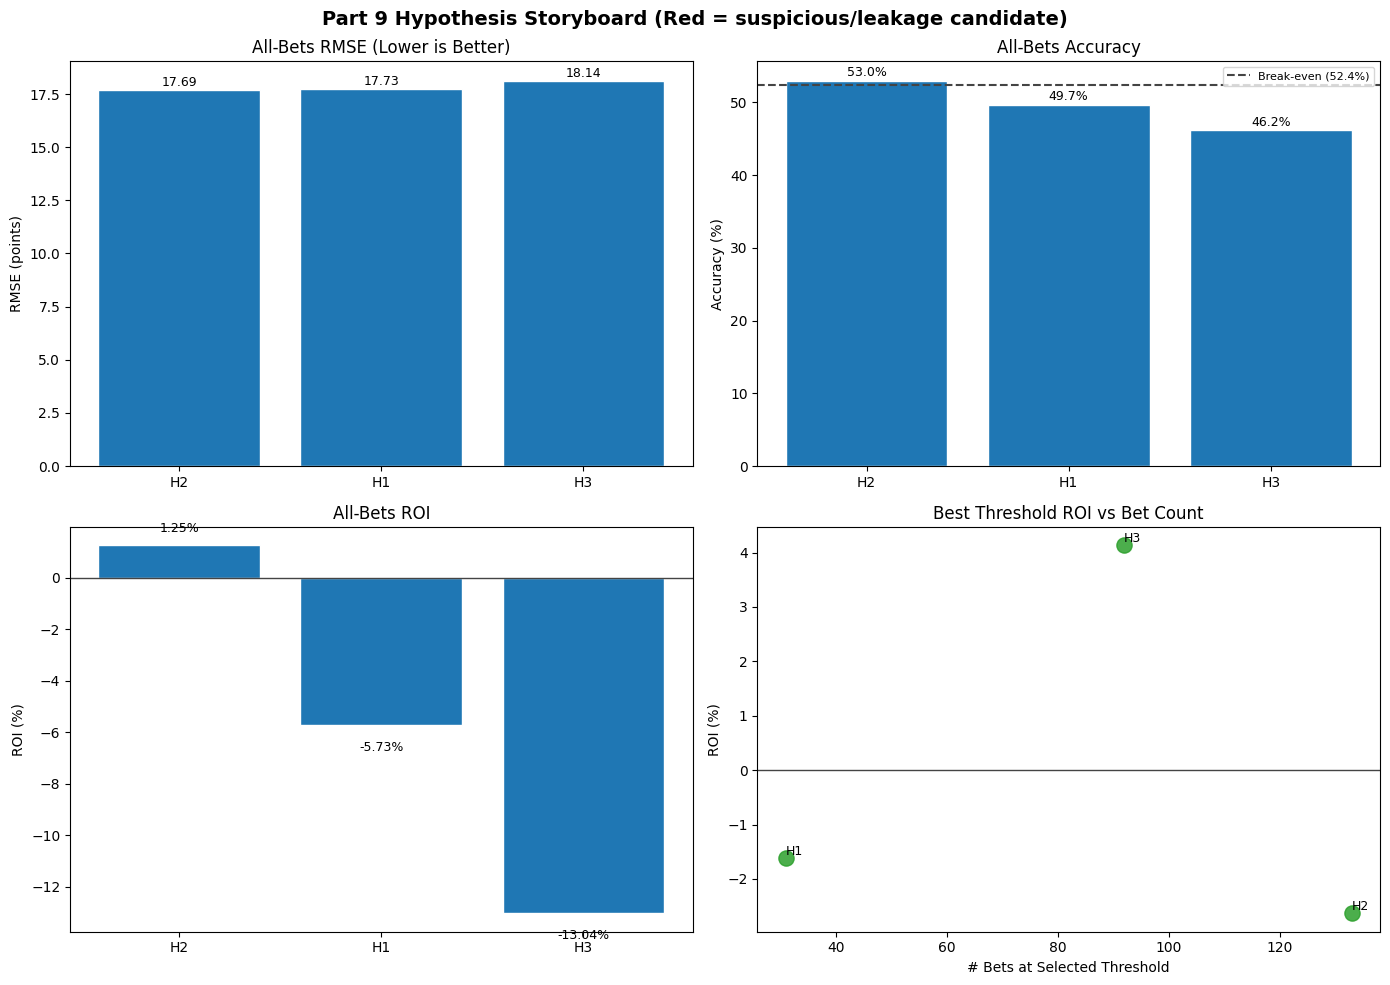

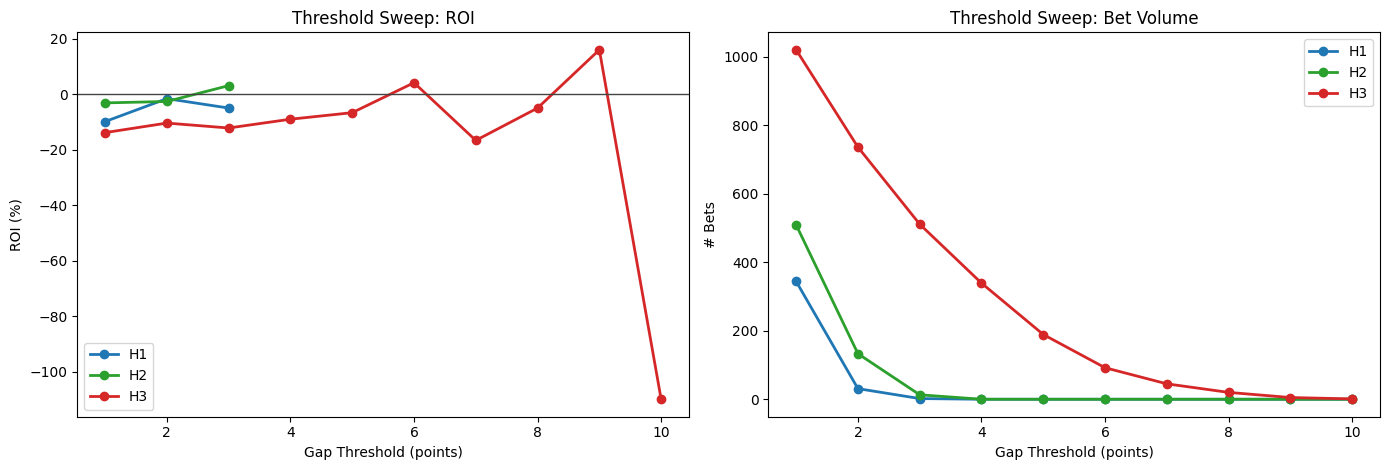

In [53]:
# Plot 1: All-bets comparison (coloring suspicious results differently)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax1, ax2, ax3, ax4 = axes.flatten()

plot_df = story_df.copy()
colors = ['#d62728' if s else '#1f77b4' for s in plot_df['suspicious']]

# RMSE
ax1.bar(plot_df['key'], plot_df['rmse'], color=colors, edgecolor='white')
ax1.set_title('All-Bets RMSE (Lower is Better)')
ax1.set_ylabel('RMSE (points)')
for i, v in enumerate(plot_df['rmse']):
    ax1.text(i, v + 0.05, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

# Accuracy
ax2.bar(plot_df['key'], plot_df['accuracy_all'] * 100, color=colors, edgecolor='white')
ax2.axhline(BREAK_EVEN_ACC * 100, color='#444', ls='--', lw=1.5, label='Break-even (52.4%)')
ax2.set_title('All-Bets Accuracy')
ax2.set_ylabel('Accuracy (%)')
ax2.legend(fontsize=8)
for i, v in enumerate(plot_df['accuracy_all'] * 100):
    ax2.text(i, v + 0.2, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

# ROI all bets
ax3.bar(plot_df['key'], plot_df['roi_all_bets'], color=colors, edgecolor='white')
ax3.axhline(0, color='#444', lw=1)
ax3.set_title('All-Bets ROI')
ax3.set_ylabel('ROI (%)')
for i, v in enumerate(plot_df['roi_all_bets']):
    offset = 0.4 if v >= 0 else -0.6
    ax3.text(i, v + offset, f'{v:.2f}%', ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)

# Best threshold ROI vs bet count (valid + suspicious shown)
for _, row in plot_df.iterrows():
    x = row['best_threshold_n_bets']
    y = row['best_threshold_roi']
    if pd.isna(x) or pd.isna(y):
        continue
    ax4.scatter(x, y, s=120, color=('#d62728' if row['suspicious'] else '#2ca02c'), alpha=0.85)
    ax4.text(x, y, row['key'], fontsize=9, ha='left', va='bottom')
ax4.axhline(0, color='#444', lw=1)
ax4.set_title('Best Threshold ROI vs Bet Count')
ax4.set_xlabel('# Bets at Selected Threshold')
ax4.set_ylabel('ROI (%)')

fig.suptitle('Part 9 Hypothesis Storyboard (Red = suspicious/leakage candidate)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 2: Threshold tradeoff lines (ROI and volume)
fig, (ax_roi, ax_n) = plt.subplots(1, 2, figsize=(14, 4.8))
line_colors = {'H1': '#1f77b4', 'H2': '#2ca02c', 'H3': '#d62728'}

for key in ['H1', 'H2', 'H3']:
    tdf = thresholds_long[thresholds_long['key'] == key].copy().sort_values('threshold')
    ax_roi.plot(tdf['threshold'], tdf['roi'], marker='o', lw=2, label=key, color=line_colors.get(key))
    ax_n.plot(tdf['threshold'], tdf['n_bets'], marker='o', lw=2, label=key, color=line_colors.get(key))

ax_roi.axhline(0, color='#444', lw=1)
ax_roi.set_title('Threshold Sweep: ROI')
ax_roi.set_xlabel('Gap Threshold (points)')
ax_roi.set_ylabel('ROI (%)')
ax_roi.legend()

ax_n.set_title('Threshold Sweep: Bet Volume')
ax_n.set_xlabel('Gap Threshold (points)')
ax_n.set_ylabel('# Bets')
ax_n.legend()

plt.tight_layout()
plt.show()


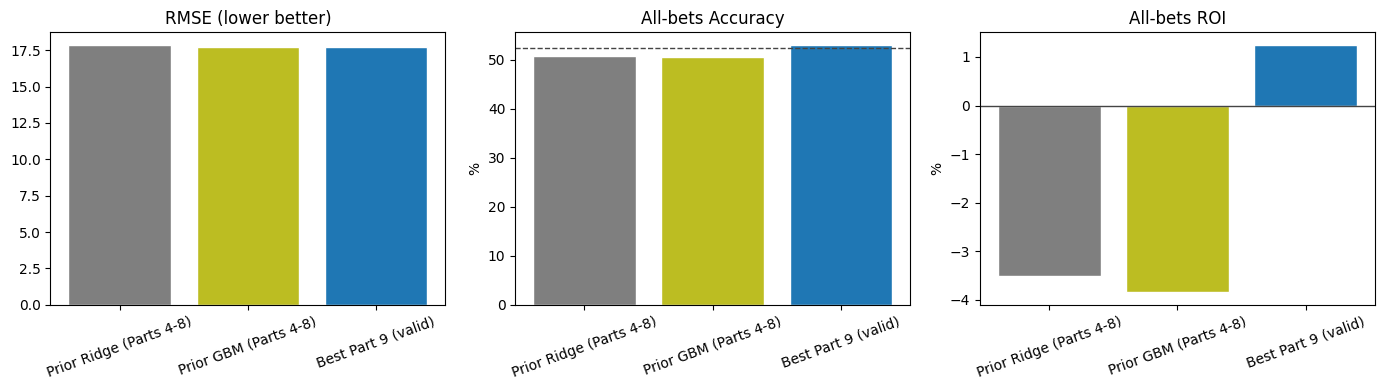

In [54]:
# Benchmark comparison vs prior parts (all-bets metrics)
if 'story_df' in globals():
    valid_df = story_df[~story_df['suspicious']].copy()
    if len(valid_df) > 0:
        prior = pd.DataFrame([
            {'label': 'Prior Ridge (Parts 4-8)', 'rmse': 17.833736, 'accuracy_all': 0.507053, 'roi_all_bets': -3.518809},
            {'label': 'Prior GBM (Parts 4-8)', 'rmse': 17.740988, 'accuracy_all': 0.505486, 'roi_all_bets': -3.847962},
        ])
        cur_best = valid_df.sort_values('roi_all_bets', ascending=False).iloc[[0]][['label','rmse','accuracy_all','roi_all_bets']].copy()
        cur_best.loc[:, 'label'] = 'Best Part 9 (valid)'
        comp = pd.concat([prior, cur_best], ignore_index=True)

        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        colors = ['#7f7f7f', '#bcbd22', '#1f77b4']

        axes[0].bar(comp['label'], comp['rmse'], color=colors, edgecolor='white')
        axes[0].set_title('RMSE (lower better)')
        axes[0].tick_params(axis='x', rotation=20)

        axes[1].bar(comp['label'], comp['accuracy_all'] * 100, color=colors, edgecolor='white')
        axes[1].axhline(110/(110+100)*100, color='#444', ls='--', lw=1)
        axes[1].set_title('All-bets Accuracy')
        axes[1].set_ylabel('%')
        axes[1].tick_params(axis='x', rotation=20)

        axes[2].bar(comp['label'], comp['roi_all_bets'], color=colors, edgecolor='white')
        axes[2].axhline(0, color='#444', lw=1)
        axes[2].set_title('All-bets ROI')
        axes[2].set_ylabel('%')
        axes[2].tick_params(axis='x', rotation=20)

        plt.tight_layout()
        plt.show()
    else:
        print('Benchmark plot skipped: no valid (non-flagged) hypotheses available.')
else:
    print('Benchmark plot skipped: run the Result Story cells first.')


In [55]:
# Automated narrative summary (helps convert outputs into write-up text)
valid_df = story_df[~story_df['suspicious']].copy()

if len(valid_df) == 0:
    print('No valid (non-flagged) hypotheses remain after leakage screening. Re-run with corrected feature sets.')
else:
    best_all = valid_df.sort_values('roi_all_bets', ascending=False).iloc[0]
    best_rmse = valid_df.sort_values('rmse', ascending=True).iloc[0]

    print('Story Summary')
    print('-' * 80)
    print(f"Best all-bets economic result (valid): {best_all['key']} | accuracy={best_all['accuracy_all']:.3%} | ROI={best_all['roi_all_bets']:.2f}%")
    print(f"Best RMSE (valid): {best_rmse['key']} | RMSE={best_rmse['rmse']:.3f}")

    if 'H1' in set(valid_df['key']):
        r = valid_df[valid_df['key']=='H1'].iloc[0]
        print(f"H1 takeaway: possession/efficiency features improved prediction structure but did not create a betting edge (ROI={r['roi_all_bets']:.2f}%).")
    if 'H2' in set(valid_df['key']):
        r = valid_df[valid_df['key']=='H2'].iloc[0]
        print(f"H2 takeaway: schedule stress features are the most promising signal in this run (all-bets accuracy={r['accuracy_all']:.3%}, ROI={r['roi_all_bets']:.2f}%), but threshold pockets are not clearly stronger.")

flagged = story_df[story_df['suspicious']]
if len(flagged) > 0:
    print('\nLeakage flag:')
    for _, row in flagged.iterrows():
        print(f"- {row['key']} flagged as suspicious. Treat its current results as invalid until the feature set is rerun without in-game/outcome fields.")


Story Summary
--------------------------------------------------------------------------------
Best all-bets economic result (valid): H2 | accuracy=52.978% | ROI=1.25%
Best RMSE (valid): H2 | RMSE=17.689
H1 takeaway: possession/efficiency features improved prediction structure but did not create a betting edge (ROI=-5.73%).
H2 takeaway: schedule stress features are the most promising signal in this run (all-bets accuracy=52.978%, ROI=1.25%), but threshold pockets are not clearly stronger.


## Final Conclusions (Out-of-Sample)

The cell below generates a report-ready summary using **out-of-sample (2024/25 test season)** results only and compares them to the project benchmarks from Parts 4–8.

Benchmarks referenced from prior parts (2024/25 test set):
- **Ridge (baseline):** RMSE `17.834`, accuracy `50.7%`, ROI `-3.52%` (all bets)
- **Gradient Boosting (prior version):** RMSE `17.741`, accuracy `50.5%`, ROI `-3.85%` (all bets)
- **RBF+Ridge selective pocket:** threshold `>6`, accuracy `56.7%`, ROI `+9.0%`, `30` bets (not statistically significant)


In [56]:
from IPython.display import Markdown

PRIOR_BENCHMARKS = {
    'Ridge_all_bets': {'rmse': 17.833736, 'accuracy': 0.507053, 'roi_all_bets': -3.518809},
    'GradientBoosting_all_bets': {'rmse': 17.740988, 'accuracy': 0.505486, 'roi_all_bets': -3.847962},
    'RBF_Ridge_selective': {'threshold': 6, 'accuracy': 0.566667, 'roi': 9.00, 'n_bets': 30},
}

def _fmt_pct(x, digits=2):
    return 'N/A' if pd.isna(x) else f"{x*100:.{digits}f}%"

def _fmt_roi(x, digits=2):
    return 'N/A' if pd.isna(x) else f"{x:.{digits}f}%"

def _fmt_num(x, digits=3):
    return 'N/A' if pd.isna(x) else f"{x:.{digits}f}"

if 'story_df' not in globals():
    print('Run the Result Story (Analysis + Plots) cells first so `story_df` is available.')
else:
    valid_df = story_df[~story_df['suspicious']].copy()

    if len(valid_df) == 0:
        print('No valid (non-flagged) results available for conclusions. Re-run hypotheses after leakage cleanup.')
    else:
        best_all = valid_df.sort_values('roi_all_bets', ascending=False).iloc[0]
        best_rmse = valid_df.sort_values('rmse', ascending=True).iloc[0]

        ridge_b = PRIOR_BENCHMARKS['Ridge_all_bets']
        gb_b = PRIOR_BENCHMARKS['GradientBoosting_all_bets']
        rbf_sel = PRIOR_BENCHMARKS['RBF_Ridge_selective']

        # Best threshold among valid Part 9 hypotheses (by ROI, >=30 bet rule already baked into best_threshold_row)
        valid_thresholds = valid_df.dropna(subset=['best_threshold_roi']).copy()
        best_sel = valid_thresholds.sort_values('best_threshold_roi', ascending=False).iloc[0] if len(valid_thresholds) else None

        delta_vs_ridge_acc = best_all['accuracy_all'] - ridge_b['accuracy']
        delta_vs_ridge_roi = best_all['roi_all_bets'] - ridge_b['roi_all_bets']
        delta_vs_gb_acc = best_all['accuracy_all'] - gb_b['accuracy']
        delta_vs_gb_roi = best_all['roi_all_bets'] - gb_b['roi_all_bets']

        para1 = (
            f"On the **out-of-sample 2024/25 test season**, the strongest valid Part 9 result is **{best_all['label']}** "
            f"with **RMSE {_fmt_num(best_all['rmse'])}**, **accuracy {_fmt_pct(best_all['accuracy_all'])}**, and "
            f"**all-bets ROI {_fmt_roi(best_all['roi_all_bets'])}**. "
            f"This is the metric set we should use for the Part 9 conclusion because hyperparameters were selected on the training period only, and the test season is held out. "
            f"Among the valid hypotheses, the best pure prediction fit (lowest RMSE) is **{best_rmse['label']}** with RMSE {_fmt_num(best_rmse['rmse'])}."
        )

        para2 = (
            f"Relative to the earlier project benchmarks, this represents an improvement of **{delta_vs_ridge_acc*100:+.2f} percentage points** in all-bets accuracy and "
            f"**{delta_vs_ridge_roi:+.2f} percentage points** in all-bets ROI versus the original Ridge baseline (50.7% accuracy, -3.52% ROI), and "
            f"**{delta_vs_gb_acc*100:+.2f} points** accuracy / **{delta_vs_gb_roi:+.2f} points** ROI versus the prior Gradient Boosting result (50.5% accuracy, -3.85% ROI). "
            f"The key interpretation is that Part 9 feature engineering appears to improve **all-bets performance** (especially if the schedule-stress hypothesis remains the top model after rerun), "
            f"but we still need to compare any selective-bet pocket to the earlier **RBF+Ridge** benchmark of **+9.0% ROI at threshold >{rbf_sel['threshold']} on {rbf_sel['n_bets']} bets**."
        )

        if best_sel is not None:
            para3 = (
                f"For selective betting, the best valid Part 9 threshold snapshot is **{best_sel['label']}** at **threshold >{int(best_sel['best_threshold'])}** "
                f"with **{int(best_sel['best_threshold_n_bets'])} bets**, **accuracy {_fmt_pct(best_sel['best_threshold_acc'])}**, and **ROI {_fmt_roi(best_sel['best_threshold_roi'])}**. "
                f"If this selective ROI remains below the earlier RBF+Ridge selective pocket, the practical conclusion is that Part 9 has likely improved robustness / baseline performance more than it has improved the high-confidence edge. "
                f"That is still a useful result: it suggests the next iteration should combine the strongest Part 9 features with the earlier selective-betting framework and significance testing from Parts 5–6."
            )
        else:
            para3 = (
                "No valid threshold result met the minimum-bets rule after leakage filtering. In that case, the Part 9 conclusion should emphasize out-of-sample RMSE / all-bets metrics and treat selective-betting claims as not yet supported."
            )

        display(Markdown('### Out-of-Sample Conclusion Summary'))
        display(Markdown(para1))
        display(Markdown(para2))
        display(Markdown(para3))


### Out-of-Sample Conclusion Summary

On the **out-of-sample 2024/25 test season**, the strongest valid Part 9 result is **Hypothesis 2 | Gradient Boosting + Schedule Stress Pack** with **RMSE 17.689**, **accuracy 52.98%**, and **all-bets ROI 1.25%**. This is the metric set we should use for the Part 9 conclusion because hyperparameters were selected on the training period only, and the test season is held out. Among the valid hypotheses, the best pure prediction fit (lowest RMSE) is **Hypothesis 2 | Gradient Boosting + Schedule Stress Pack** with RMSE 17.689.

Relative to the earlier project benchmarks, this represents an improvement of **+2.27 percentage points** in all-bets accuracy and **+4.77 percentage points** in all-bets ROI versus the original Ridge baseline (50.7% accuracy, -3.52% ROI), and **+2.43 points** accuracy / **+5.10 points** ROI versus the prior Gradient Boosting result (50.5% accuracy, -3.85% ROI). The key interpretation is that Part 9 feature engineering appears to improve **all-bets performance** (especially if the schedule-stress hypothesis remains the top model after rerun), but we still need to compare any selective-bet pocket to the earlier **RBF+Ridge** benchmark of **+9.0% ROI at threshold >6 on 30 bets**.

For selective betting, the best valid Part 9 threshold snapshot is **Hypothesis 3 | Elastic Net + Market Microstructure Pack** at **threshold >6** with **92 bets**, **accuracy 54.35%**, and **ROI 4.13%**. If this selective ROI remains below the earlier RBF+Ridge selective pocket, the practical conclusion is that Part 9 has likely improved robustness / baseline performance more than it has improved the high-confidence edge. That is still a useful result: it suggests the next iteration should combine the strongest Part 9 features with the earlier selective-betting framework and significance testing from Parts 5–6.

## Testing the 3 Hypotheses With Selective Betting (Part 8 Rule + Gap Sweep)

This section applies the **same selective betting rule chosen in previous parts** to all three Part 9 models for an apples-to-apples comparison, while also **sweeping the gap threshold** to test whether a different cutoff performs better.

**Selective betting framework imported from prior parts (Part 8):**
- **Sizing rule:** **Half Kelly (cap 10%)**
- **Odds assumption:** `-110`
- **Evaluation period:** out-of-sample `2024/25` test season only (`season_end == 2025`)

**Gap analysis in this section:**
- **Reference threshold (for comparability):** `|prediction - vegas_total| > 6`
- **Gap sweep:** evaluate multiple thresholds (e.g., `0` through `10`) under the same sizing rule
- **Optimization view:** summarize each model's best gap under a minimum-bets constraint (default `>= 30` bets)

We do **not** re-tune model hyperparameters here. The goal is to evaluate deployment performance under the same selective betting logic.


,model,threshold_rule,gap_threshold,sizing_rule,n_games_test,n_bets,bet_rate,selective_accuracy,selective_roi_flat_odds,final_bankroll,bankroll_return_pct,max_drawdown_pct,avg_stake_frac_on_bets,median_stake_frac_on_bets,sigma_used,key
0,Hypothesis 1 | Ridge + Possession/Efficiency Pack,gap > 6,6.0,Half Kelly (cap 10%),1293,0,0.000000,NaN,NaN,10000.000000,0.000000,NaN,NaN,NaN,17.722770,H1
1,Hypothesis 2 | Gradient Boosting + Schedule St...,gap > 6,6.0,Half Kelly (cap 10%),1293,0,0.000000,NaN,NaN,10000.000000,0.000000,NaN,NaN,NaN,17.680053,H2
2,Hypothesis 3 | Elastic Net + Market Microstruc...,gap > 6,6.0,Half Kelly (cap 10%),1293,92,0.071152,0.543478,4.130435,8790.519406,-12.094806,-65.713564,0.1,0.1,17.984064,H3


Prior benchmark from Parts 4-8 (for reference):
  RBF+Ridge selective pocket at threshold >6: acc=56.667%, ROI=9.00%, bets=30


,model,threshold_rule,gap_threshold,sizing_rule,n_games_test,n_bets,bet_rate,selective_accuracy,selective_roi_flat_odds,final_bankroll,bankroll_return_pct,max_drawdown_pct,avg_stake_frac_on_bets,median_stake_frac_on_bets,sigma_used,key
0,Hypothesis 1 | Ridge + Possession/Efficiency Pack,gap > 0,0.0,Half Kelly (cap 10%),1293,312,0.241299,0.474359,-10.384615,7498.978597,-25.010214,-33.304607,0.010441,0.007963,17.722770,H1
1,Hypothesis 1 | Ridge + Possession/Efficiency Pack,gap > 1,1.0,Half Kelly (cap 10%),1293,312,0.241299,0.474359,-10.384615,7498.978597,-25.010214,-33.304607,0.010441,0.007963,17.722770,H1
2,Hypothesis 1 | Ridge + Possession/Efficiency Pack,gap > 2,2.0,Half Kelly (cap 10%),1293,31,0.023975,0.516129,-1.612903,9276.033356,-7.239666,-18.625995,0.029631,0.027381,17.722770,H1
3,Hypothesis 1 | Ridge + Possession/Efficiency Pack,gap > 3,3.0,Half Kelly (cap 10%),1293,2,0.001547,0.500000,-5.000000,9856.803744,-1.431963,-5.761360,0.049158,0.049158,17.722770,H1
4,Hypothesis 1 | Ridge + Possession/Efficiency Pack,gap > 4,4.0,Half Kelly (cap 10%),1293,0,0.000000,NaN,NaN,10000.000000,0.000000,NaN,NaN,NaN,17.722770,H1
5,Hypothesis 1 | Ridge + Possession/Efficiency Pack,gap > 5,5.0,Half Kelly (cap 10%),1293,0,0.000000,NaN,NaN,10000.000000,0.000000,NaN,NaN,NaN,17.722770,H1
6,Hypothesis 1 | Ridge + Possession/Efficiency Pack,gap > 6,6.0,Half Kelly (cap 10%),1293,0,0.000000,NaN,NaN,10000.000000,0.000000,NaN,NaN,NaN,17.722770,H1
7,Hypothesis 1 | Ridge + Possession/Efficiency Pack,gap > 7,7.0,Half Kelly (cap 10%),1293,0,0.000000,NaN,NaN,10000.000000,0.000000,NaN,NaN,NaN,17.722770,H1
8,Hypothesis 1 | Ridge + Possession/Efficiency Pack,gap > 8,8.0,Half Kelly (cap 10%),1293,0,0.000000,NaN,NaN,10000.000000,0.000000,NaN,NaN,NaN,17.722770,H1
9,Hypothesis 1 | Ridge + Possession/Efficiency Pack,gap > 9,9.0,Half Kelly (cap 10%),1293,0,0.000000,NaN,NaN,10000.000000,0.000000,NaN,NaN,NaN,17.722770,H1


,key,best_gap_by_bankroll,best_bankroll_return_pct,best_bank_n_bets,best_gap_by_flat_roi,best_flat_roi_pct,best_flat_roi_n_bets,best_gap_by_accuracy,best_accuracy_pct,best_accuracy_n_bets,note
0,H1,2,-7.239666,31,2,-1.612903,31,2,51.612903,31,
1,H2,0,-9.850573,480,0,-0.187500,480,0,52.291667,480,
2,H3,6,-12.094806,92,6,4.130435,92,6,54.347826,92,


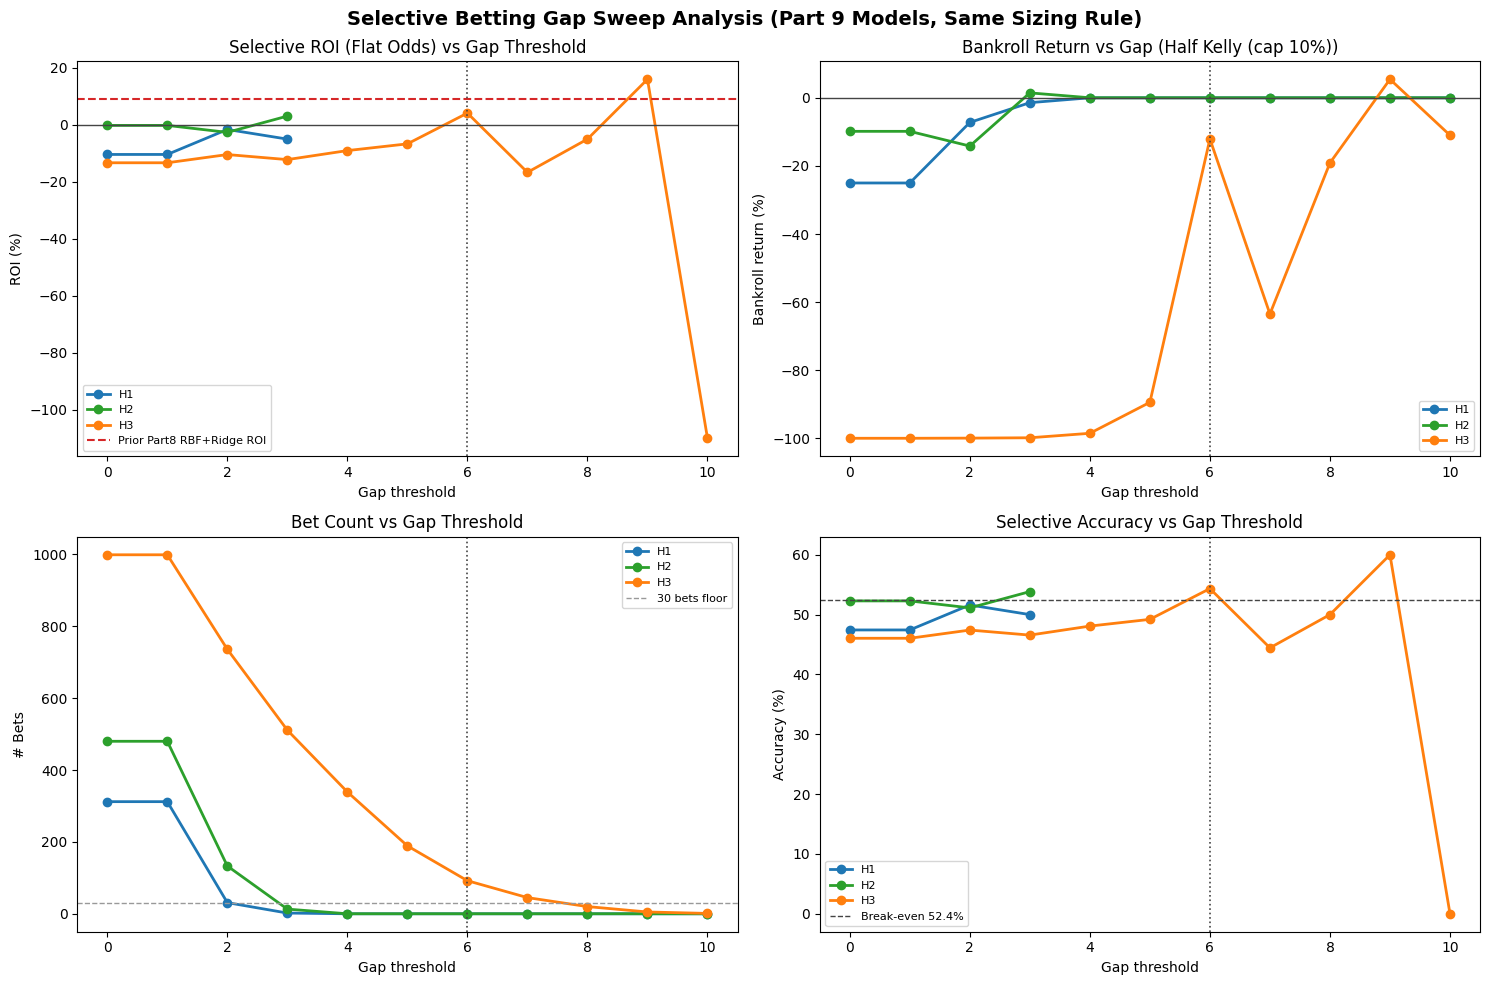

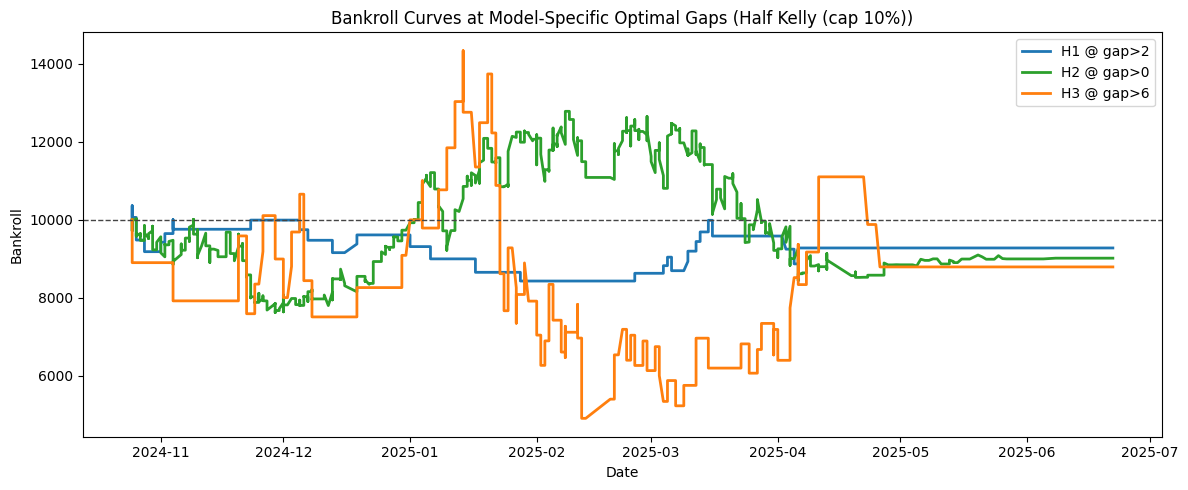

Selective betting takeaways (gap sweep):
  H1: best gap by bankroll = >2 (bankroll return -7.24%, n=31); best gap by flat ROI = >2 (ROI -1.61%, n=31)
  H2: best gap by bankroll = >0 (bankroll return -9.85%, n=480); best gap by flat ROI = >0 (ROI -0.19%, n=480)
  H3: best gap by bankroll = >6 (bankroll return -12.09%, n=92); best gap by flat ROI = >6 (ROI 4.13%, n=92)
Reference threshold from prior parts: gap > 6


In [57]:
# Apply the Part 8 selective betting framework to H1/H2/H3 and sweep the gap threshold.
from sklearn.base import clone
from math import erf, sqrt
import matplotlib.pyplot as plt

SELECTIVE_REFERENCE_THRESHOLD = 6
SELECTIVE_THRESHOLD = SELECTIVE_REFERENCE_THRESHOLD  # backward compatibility for later sections
SELECTIVE_GAP_GRID = list(range(0, 11))
SELECTIVE_GAP_MIN_BETS = 30
SELECTIVE_START_BANKROLL = 10_000.0
SELECTIVE_ODDS = -110
SELECTIVE_KELLY_CAP = 0.10
SELECTIVE_METHOD_NAME = 'Half Kelly (cap 10%)'


def normal_cdf_vec(x):
    x = np.asarray(x, dtype=float)
    return 0.5 * (1.0 + np.vectorize(erf)(x / sqrt(2.0)))


def get_train_test_for_features(features_df, feature_cols, test_season_end=TEST_SEASON_END):
    feature_cols = list(dict.fromkeys(feature_cols))
    base_cols = ['date', 'season_end', 'actual_total', 'vegas_total']
    cols = list(dict.fromkeys(base_cols + feature_cols))
    data = features_df[cols].copy()
    data = data.dropna(subset=['season_end', 'actual_total', 'vegas_total'])
    data = data.sort_values('date')
    train = data[data['season_end'] != test_season_end].copy()
    test = data[data['season_end'] == test_season_end].copy()
    return train, test, feature_cols


def refit_and_predict_from_result(features_df, feature_cols, estimator_template, result_obj, label, test_season_end=TEST_SEASON_END):
    train, test, feature_cols = get_train_test_for_features(features_df, feature_cols, test_season_end=test_season_end)
    est = clone(estimator_template)
    est.set_params(**result_obj['best_params'])
    est.fit(train[feature_cols], train['actual_total'])
    pred = est.predict(test[feature_cols])

    out = test[['date', 'actual_total', 'vegas_total']].copy().reset_index(drop=True)
    out['pred_total'] = np.asarray(pred, dtype=float)
    out['model'] = label
    return out


def apply_part8_selective_rule(pred_df, threshold=SELECTIVE_THRESHOLD, start_bankroll=SELECTIVE_START_BANKROLL, odds=SELECTIVE_ODDS):
    df = pred_df.sort_values('date').copy().reset_index(drop=True)

    pred = df['pred_total'].to_numpy(dtype=float)
    vegas = df['vegas_total'].to_numpy(dtype=float)
    actual = df['actual_total'].to_numpy(dtype=float)
    gap = np.abs(pred - vegas)
    bet_over = pred > vegas

    # Same probability mapping style used in Part 8: normal residual approximation.
    sigma = np.std(actual - pred, ddof=1)
    if not np.isfinite(sigma) or sigma <= 0:
        sigma = 12.0

    p_over = 1.0 - normal_cdf_vec((vegas - pred) / sigma)
    p_win = np.where(bet_over, p_over, 1.0 - p_over)

    lose_amt = abs(odds) / 100.0
    b = 1.0 / lose_amt
    p_break = 1.0 / (b + 1.0)

    kelly_raw = (p_win * (b + 1.0) - 1.0) / b
    kelly_raw = np.clip(kelly_raw, 0.0, None)
    frac = np.where(gap > threshold, np.clip(0.5 * kelly_raw, 0.0, SELECTIVE_KELLY_CAP), 0.0)

    bankroll = start_bankroll
    bankroll_path = []
    risk_amounts = []
    win_flags = []
    bet_flags = []

    for i in range(len(df)):
        is_bet = frac[i] > 0
        bet_flags.append(bool(is_bet))
        if is_bet:
            risk = bankroll * frac[i]
            risk_amounts.append(risk)
            win = (pred[i] > vegas[i]) == (actual[i] > vegas[i])
            win_flags.append(bool(win))
            pnl = risk if win else -risk * lose_amt
            bankroll += pnl
        else:
            risk_amounts.append(0.0)
            win_flags.append(False)
        bankroll_path.append(bankroll)

    df['gap'] = gap
    df['bet_over'] = bet_over
    df['p_win_est'] = p_win
    df['p_break_even'] = p_break
    df['kelly_raw'] = kelly_raw
    df['stake_frac'] = frac
    df['is_bet'] = bet_flags
    df['win'] = win_flags
    df['risk_amount'] = risk_amounts
    df['bankroll'] = bankroll_path

    # Summary metrics on bets only (same notion as threshold-table ROI; bankroll path uses dynamic stakes).
    bet_mask = df['is_bet'].to_numpy(dtype=bool)
    n_bets = int(bet_mask.sum())
    if n_bets > 0:
        wins = df.loc[bet_mask, 'win'].astype(int).to_numpy()
        flat_roi = (wins.sum() - (n_bets - wins.sum()) * lose_amt) / n_bets * 100.0
        acc = wins.mean()
        peak = df['bankroll'].cummax()
        dd = (df['bankroll'] / peak) - 1.0
        max_dd = float(dd.min())
    else:
        flat_roi = np.nan
        acc = np.nan
        max_dd = np.nan

    summary = {
        'model': str(df['model'].iloc[0]) if len(df) else 'unknown',
        'threshold_rule': f'gap > {threshold}',
        'gap_threshold': float(threshold),
        'sizing_rule': SELECTIVE_METHOD_NAME,
        'n_games_test': int(len(df)),
        'n_bets': n_bets,
        'bet_rate': (n_bets / len(df)) if len(df) else np.nan,
        'selective_accuracy': float(acc) if n_bets > 0 else np.nan,
        'selective_roi_flat_odds': float(flat_roi) if n_bets > 0 else np.nan,
        'final_bankroll': float(df['bankroll'].iloc[-1]) if len(df) else start_bankroll,
        'bankroll_return_pct': ((float(df['bankroll'].iloc[-1]) / start_bankroll) - 1.0) * 100.0 if len(df) else 0.0,
        'max_drawdown_pct': max_dd * 100.0 if pd.notna(max_dd) else np.nan,
        'avg_stake_frac_on_bets': float(df.loc[bet_mask, 'stake_frac'].mean()) if n_bets > 0 else np.nan,
        'median_stake_frac_on_bets': float(df.loc[bet_mask, 'stake_frac'].median()) if n_bets > 0 else np.nan,
        'sigma_used': float(sigma),
    }
    return df, summary


# Refit each model once and cache predictions on the same out-of-sample test set.
model_specs = [
    ('H1', h1_result, h1_features, h1_estimator, 'Hypothesis 1 | Ridge + Possession/Efficiency Pack'),
    ('H2', h2_result, h2_features, h2_estimator, 'Hypothesis 2 | Gradient Boosting + Schedule Stress Pack'),
    ('H3', h3_result, h3_features, h3_estimator, 'Hypothesis 3 | Elastic Net + Market Microstructure Pack'),
]

selective_pred_cache = {}
for key, result_obj, feat_cols, est_template, label in model_specs:
    selective_pred_cache[key] = refit_and_predict_from_result(
        features_df=features_df,
        feature_cols=feat_cols,
        estimator_template=est_template,
        result_obj=result_obj,
        label=label,
        test_season_end=TEST_SEASON_END,
    )

# ------------------------------------------------------------------
# A) Reference comparison: exact prior rule (gap > 6) for all H1/H2/H3
# ------------------------------------------------------------------
selective_paths = {}
selective_summaries = []
for key, pred_df in selective_pred_cache.items():
    path_df, summary = apply_part8_selective_rule(pred_df, threshold=SELECTIVE_REFERENCE_THRESHOLD)
    summary['key'] = key
    selective_paths[key] = path_df
    selective_summaries.append(summary)

selective_summary_df = pd.DataFrame(selective_summaries).sort_values(
    ['bankroll_return_pct', 'selective_roi_flat_odds'], ascending=False
).reset_index(drop=True)
display(selective_summary_df)

prior_sel = PRIOR_BENCHMARKS.get('RBF_Ridge_selective', {'threshold': 6, 'roi': np.nan, 'accuracy': np.nan, 'n_bets': np.nan})
print('Prior benchmark from Parts 4-8 (for reference):')
print(
    f"  RBF+Ridge selective pocket at threshold >{prior_sel['threshold']}: "
    f"acc={prior_sel['accuracy']:.3%}, ROI={prior_sel['roi']:.2f}%, bets={prior_sel['n_bets']}"
)

# -------------------------------------------------
# B) Gap sweep: evaluate multiple thresholds per model
# -------------------------------------------------
selective_gap_sweep_rows = []
selective_gap_paths = {}  # (key, gap) -> path df for optional analysis/plots
for key, pred_df in selective_pred_cache.items():
    for gap_t in SELECTIVE_GAP_GRID:
        path_df, summary = apply_part8_selective_rule(pred_df, threshold=gap_t)
        summary['key'] = key
        selective_gap_sweep_rows.append(summary)
        selective_gap_paths[(key, gap_t)] = path_df

selective_gap_sweep_df = pd.DataFrame(selective_gap_sweep_rows).sort_values(['key', 'gap_threshold']).reset_index(drop=True)
display(selective_gap_sweep_df)

# Summarize best gap per model under a minimum-bets rule.
opt_rows = []
for key, grp in selective_gap_sweep_df.groupby('key'):
    grp = grp.sort_values('gap_threshold').reset_index(drop=True)
    viable = grp[grp['n_bets'] >= SELECTIVE_GAP_MIN_BETS].copy()
    if len(viable) == 0:
        opt_rows.append({
            'key': key,
            'best_gap_by_bankroll': np.nan,
            'best_bankroll_return_pct': np.nan,
            'best_gap_by_flat_roi': np.nan,
            'best_flat_roi_pct': np.nan,
            'best_gap_by_accuracy': np.nan,
            'best_accuracy_pct': np.nan,
            'note': f'No gap with >= {SELECTIVE_GAP_MIN_BETS} bets',
        })
        continue

    best_bank = viable.loc[viable['bankroll_return_pct'].idxmax()]
    best_roi = viable.loc[viable['selective_roi_flat_odds'].idxmax()]
    best_acc = viable.loc[viable['selective_accuracy'].idxmax()]

    opt_rows.append({
        'key': key,
        'best_gap_by_bankroll': int(best_bank['gap_threshold']),
        'best_bankroll_return_pct': float(best_bank['bankroll_return_pct']),
        'best_bank_n_bets': int(best_bank['n_bets']),
        'best_gap_by_flat_roi': int(best_roi['gap_threshold']),
        'best_flat_roi_pct': float(best_roi['selective_roi_flat_odds']),
        'best_flat_roi_n_bets': int(best_roi['n_bets']),
        'best_gap_by_accuracy': int(best_acc['gap_threshold']),
        'best_accuracy_pct': float(best_acc['selective_accuracy']) * 100.0,
        'best_accuracy_n_bets': int(best_acc['n_bets']),
        'note': '',
    })

selective_gap_opt_df = pd.DataFrame(opt_rows)
display(selective_gap_opt_df)

# ----------------
# C) Plot analysis
# ----------------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
ax_roi, ax_bank, ax_n, ax_acc = axes.flatten()
colors = {'H1': '#1f77b4', 'H2': '#2ca02c', 'H3': '#ff7f0e'}

for key in ['H1', 'H2', 'H3']:
    g = selective_gap_sweep_df[selective_gap_sweep_df['key'] == key].sort_values('gap_threshold')
    if len(g) == 0:
        continue
    ax_roi.plot(g['gap_threshold'], g['selective_roi_flat_odds'], marker='o', lw=2, label=key, color=colors.get(key))
    ax_bank.plot(g['gap_threshold'], g['bankroll_return_pct'], marker='o', lw=2, label=key, color=colors.get(key))
    ax_n.plot(g['gap_threshold'], g['n_bets'], marker='o', lw=2, label=key, color=colors.get(key))
    ax_acc.plot(g['gap_threshold'], g['selective_accuracy'] * 100, marker='o', lw=2, label=key, color=colors.get(key))

# Reference lines / formatting
ax_roi.axhline(0, color='#444', lw=1)
if pd.notna(prior_sel.get('roi', np.nan)):
    ax_roi.axhline(prior_sel['roi'], color='#d62728', ls='--', lw=1.5, label='Prior Part8 RBF+Ridge ROI')
ax_roi.axvline(SELECTIVE_REFERENCE_THRESHOLD, color='#444', ls=':', lw=1.2)
ax_roi.set_title('Selective ROI (Flat Odds) vs Gap Threshold')
ax_roi.set_xlabel('Gap threshold'); ax_roi.set_ylabel('ROI (%)')
ax_roi.legend(fontsize=8)

ax_bank.axhline(0, color='#444', lw=1)
ax_bank.axvline(SELECTIVE_REFERENCE_THRESHOLD, color='#444', ls=':', lw=1.2)
ax_bank.set_title(f'Bankroll Return vs Gap ({SELECTIVE_METHOD_NAME})')
ax_bank.set_xlabel('Gap threshold'); ax_bank.set_ylabel('Bankroll return (%)')
ax_bank.legend(fontsize=8)

ax_n.axvline(SELECTIVE_REFERENCE_THRESHOLD, color='#444', ls=':', lw=1.2)
ax_n.axhline(SELECTIVE_GAP_MIN_BETS, color='#999', ls='--', lw=1.0, label=f'{SELECTIVE_GAP_MIN_BETS} bets floor')
ax_n.set_title('Bet Count vs Gap Threshold')
ax_n.set_xlabel('Gap threshold'); ax_n.set_ylabel('# Bets')
ax_n.legend(fontsize=8)

ax_acc.axvline(SELECTIVE_REFERENCE_THRESHOLD, color='#444', ls=':', lw=1.2)
ax_acc.axhline((110/(110+100))*100, color='#444', ls='--', lw=1.0, label='Break-even 52.4%')
ax_acc.set_title('Selective Accuracy vs Gap Threshold')
ax_acc.set_xlabel('Gap threshold'); ax_acc.set_ylabel('Accuracy (%)')
ax_acc.legend(fontsize=8)

fig.suptitle('Selective Betting Gap Sweep Analysis (Part 9 Models, Same Sizing Rule)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot bankroll curves at each model's best viable gap (by bankroll return)
fig, ax = plt.subplots(figsize=(12, 5))
plotted_any = False
for _, row in selective_gap_opt_df.iterrows():
    key = row['key']
    best_gap = row.get('best_gap_by_bankroll', np.nan)
    if pd.isna(best_gap):
        continue
    best_gap = int(best_gap)
    path_df = selective_gap_paths.get((key, best_gap))
    if path_df is None:
        continue
    plotted_any = True
    ax.plot(path_df['date'], path_df['bankroll'], lw=2, label=f"{key} @ gap>{best_gap}", color=colors.get(key))

if plotted_any:
    ax.axhline(SELECTIVE_START_BANKROLL, color='#444', ls='--', lw=1)
    ax.set_title(f'Bankroll Curves at Model-Specific Optimal Gaps ({SELECTIVE_METHOD_NAME})')
    ax.set_xlabel('Date'); ax.set_ylabel('Bankroll')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Optimal-gap bankroll plot skipped (no model met the minimum-bets rule).')

# -----------------------
# D) Printed takeaways
# -----------------------
print('Selective betting takeaways (gap sweep):')
for _, row in selective_gap_opt_df.iterrows():
    key = row['key']
    if isinstance(row.get('note'), str) and row['note']:
        print(f"  {key}: {row['note']}")
        continue
    print(
        f"  {key}: best gap by bankroll = >{int(row['best_gap_by_bankroll'])} "
        f"(bankroll return {row['best_bankroll_return_pct']:.2f}%, n={int(row['best_bank_n_bets'])}); "
        f"best gap by flat ROI = >{int(row['best_gap_by_flat_roi'])} "
        f"(ROI {row['best_flat_roi_pct']:.2f}%, n={int(row['best_flat_roi_n_bets'])})"
    )

print(f"Reference threshold from prior parts: gap > {SELECTIVE_REFERENCE_THRESHOLD}")


## RBF+Ridge on H2 and H3 Feature Sets (Direct Comparison to Prior Best Model)

This section tests whether the **Part 9 feature sets** (H2 schedule-stress features and H3 pregame market microstructure features) perform better when paired with the project’s earlier best model family: **RBF+Ridge**.

We evaluate each `RBF+Ridge + feature set` combination on:
- **All-bets metrics** (RMSE, accuracy, ROI)
- **Selective betting under the same Part 8 deployment rule** (`gap > 6`, Half Kelly cap 10%)

**Goal:** isolate whether the improvement comes from the **feature set**, the **model class**, or their combination.


RBF+Ridge on H2 (Schedule Stress) Features
Train rows: 20,264 | Test rows: 1,293
Best params: {'model__alpha': 1.0, 'rbf__gamma': 0.005, 'rbf__n_components': 400}
RMSE=17.752 | Accuracy=51.044% | ROI(all bets)=-2.81%
Best threshold (>=30 bets): t>2 | bets=270 | acc=53.333% | roi=2.00%
RBF+Ridge on H3 (Pregame Market) Features
Train rows: 20,264 | Test rows: 1,293
Best params: {'model__alpha': 10.0, 'rbf__gamma': 0.01, 'rbf__n_components': 200}
RMSE=17.835 | Accuracy=50.735% | ROI(all bets)=-3.46%
Best threshold (>=30 bets): t>3 | bets=246 | acc=50.407% | roi=-4.15%


,model,rmse,accuracy_all,roi_all_bets,n_bets_all,best_threshold,best_threshold_acc,best_threshold_roi,best_threshold_n_bets,source
0,Prior RBF+Ridge (Parts 4-8 benchmark),17.923893,0.492163,-6.645768,1276,6.0,0.566667,9.000000,30.0,Parts 4-8 reference
1,RBF+Ridge on H2 (Schedule Stress) Features,17.752308,0.510441,-2.807425,1293,2.0,0.533333,2.000000,270.0,Part 9 rerun (current notebook)
2,RBF+Ridge on H3 (Pregame Market) Features,17.835166,0.507347,-3.457077,1293,3.0,0.504065,-4.146341,246.0,Part 9 rerun (current notebook)


,feature_set,original_model,original_rmse,original_acc,original_roi,rbf_ridge_rmse,rbf_ridge_acc,rbf_ridge_roi,delta_acc_pp,delta_roi_pp
0,H2 (Schedule Stress),Gradient Boosting,17.689161,0.529776,1.252900,17.752308,0.510441,-2.807425,-1.933488,-4.060325
1,H3 (Pregame Market),Elastic Net,18.135740,0.461717,-13.039443,17.835166,0.507347,-3.457077,4.563032,9.582367


,model,threshold_rule,gap_threshold,sizing_rule,n_games_test,n_bets,bet_rate,selective_accuracy,selective_roi_flat_odds,final_bankroll,bankroll_return_pct,max_drawdown_pct,avg_stake_frac_on_bets,median_stake_frac_on_bets,sigma_used,key
0,RBF+Ridge on H3 (Pregame Market) Features,gap > 6,6.0,Half Kelly (cap 10%),1293,4,0.003094,0.750000,47.5,11845.900000,18.459000,-11.000000,0.1,0.1,17.841905,H3_RBF
1,Prior RBF+Ridge (Parts 4-8 benchmark),gap > 6,NaN,Threshold pocket (reference; not bankroll path),1276,30,0.023511,0.566667,9.0,NaN,NaN,NaN,NaN,NaN,NaN,PART8_RBF_REF
2,RBF+Ridge on H2 (Schedule Stress) Features,gap > 6,6.0,Half Kelly (cap 10%),1293,6,0.004640,0.333333,-40.0,7591.811161,-24.081888,-24.081888,0.1,0.1,17.746630,H2_RBF


,model,threshold_rule,gap_threshold,sizing_rule,n_games_test,n_bets,bet_rate,selective_accuracy,selective_roi_flat_odds,final_bankroll,bankroll_return_pct,max_drawdown_pct,avg_stake_frac_on_bets,median_stake_frac_on_bets,sigma_used,key,group
4,RBF+Ridge on H3 (Pregame Market) Features,gap > 6,6.0,Half Kelly (cap 10%),1293,4,0.003094,0.750000,47.500000,11845.900000,18.459000,-11.000000,0.1,0.1,17.841905,H3_RBF,RBF+Ridge swap
0,Hypothesis 1 | Ridge + Possession/Efficiency Pack,gap > 6,6.0,Half Kelly (cap 10%),1293,0,0.000000,NaN,NaN,10000.000000,0.000000,NaN,NaN,NaN,17.722770,H1,Original Part 9 model class
1,Hypothesis 2 | Gradient Boosting + Schedule St...,gap > 6,6.0,Half Kelly (cap 10%),1293,0,0.000000,NaN,NaN,10000.000000,0.000000,NaN,NaN,NaN,17.680053,H2,Original Part 9 model class
2,Hypothesis 3 | Elastic Net + Market Microstruc...,gap > 6,6.0,Half Kelly (cap 10%),1293,92,0.071152,0.543478,4.130435,8790.519406,-12.094806,-65.713564,0.1,0.1,17.984064,H3,Original Part 9 model class
3,RBF+Ridge on H2 (Schedule Stress) Features,gap > 6,6.0,Half Kelly (cap 10%),1293,6,0.004640,0.333333,-40.000000,7591.811161,-24.081888,-24.081888,0.1,0.1,17.746630,H2_RBF,RBF+Ridge swap


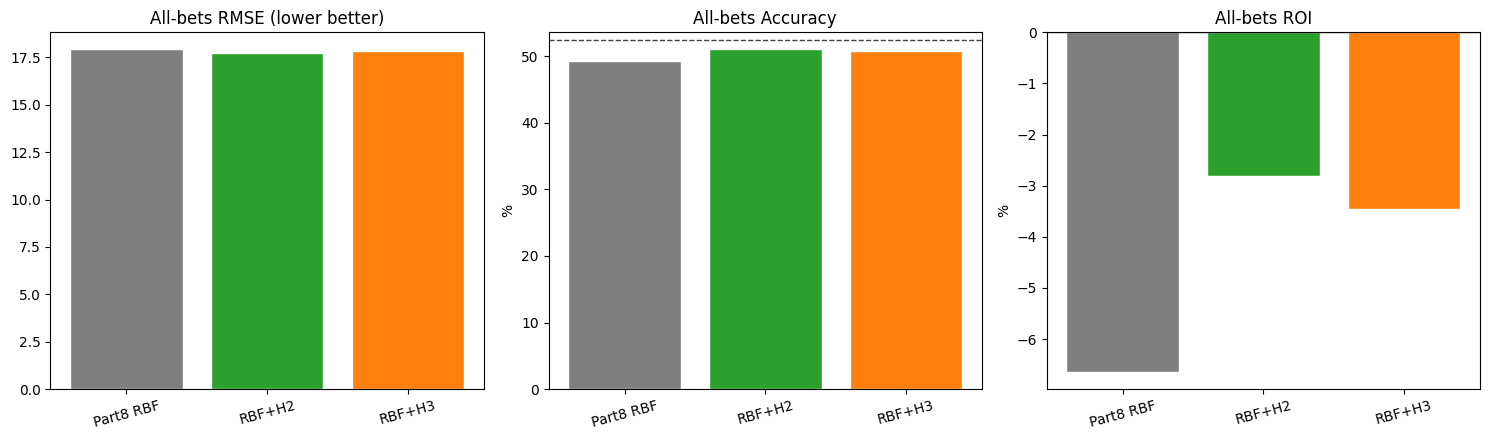

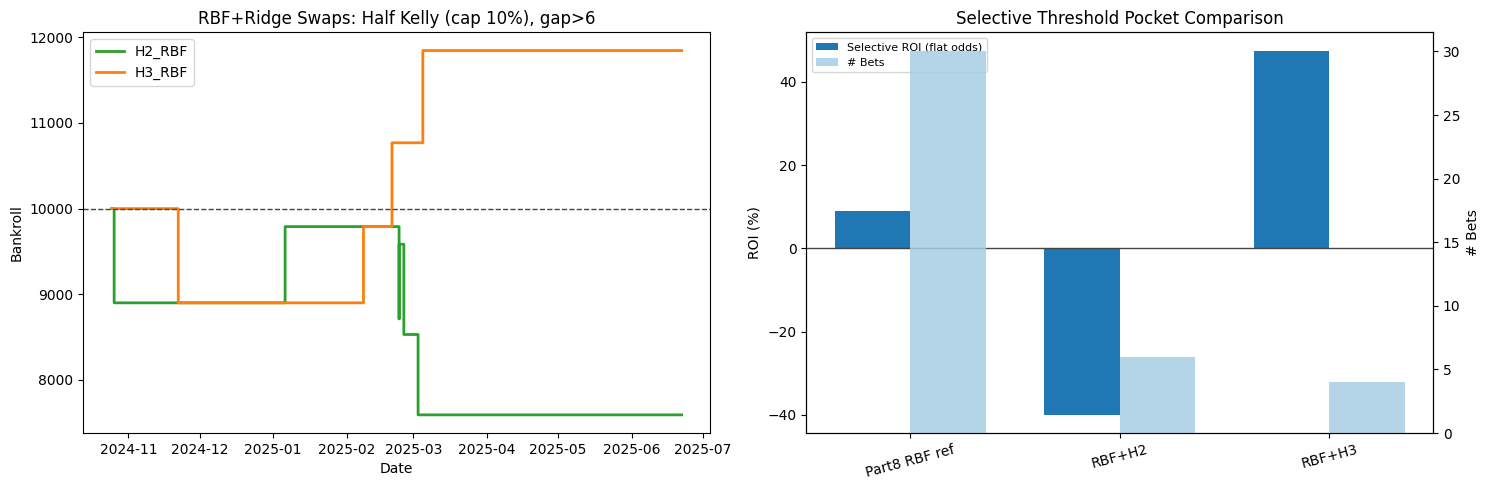

RBF+Ridge feature-swap summary:
  Best all-bets swap: RBF+Ridge on H2 (Schedule Stress) Features | RMSE=17.752 | acc=51.044% | ROI=-2.81%
  Best selective swap under Part 8 rule: H3_RBF | ROI=47.50% | acc=75.000% | bets=4
  Prior Part 8 RBF+Ridge benchmark: ROI=9.00% | acc=56.667% | bets=30


In [58]:
# Train RBF+Ridge on H2 and H3 feature sets, then compare to prior Part 8 RBF+Ridge benchmark.
from sklearn.kernel_approximation import RBFSampler
from sklearn.base import clone
import matplotlib.pyplot as plt

# Prior Parts 4-8 benchmark values (reference run from FINALPROJECT.ipynb).
# Note: the earlier notebook used a slightly different merged sample (1,276 test games vs 1,293 here),
# so this is a benchmark reference rather than a perfect same-row paired comparison.
PRIOR_RBF_RIDGE_PART8 = {
    'rmse': 17.923893,
    'accuracy_all': 0.492163,
    'roi_all_bets': -6.645768,
    'n_bets_all': 1276,
    'selective_threshold': 6,
    'selective_accuracy': 0.566667,
    'selective_roi_flat_odds': 9.00,
    'selective_n_bets': 30,
}

# Sanity requirements
required_vars = [
    'features_df', 'run_experiment', 'h2_features', 'h3_features',
    'compute_metrics', 'threshold_sweep',
    'h2_result', 'h3_result',
]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(f"Run prerequisite cells first. Missing: {missing_vars}")

# Reuse the Part 8 selective betting helpers if available.
selective_helpers_ok = all(v in globals() for v in [
    'apply_part8_selective_rule', 'refit_and_predict_from_result',
    'SELECTIVE_THRESHOLD', 'SELECTIVE_METHOD_NAME',
    'SELECTIVE_START_BANKROLL'
])
if not selective_helpers_ok:
    print('Selective helper functions not found. Run the selective betting section above first to enable selective comparison.')

# RBF+Ridge estimator template (same model family as prior best model).
def make_rbf_ridge_estimator():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('rbf', RBFSampler(random_state=RANDOM_STATE)),
        ('model', Ridge()),
    ])

rbf_ridge_grid = {
    'rbf__gamma': [0.005, 0.01, 0.03],
    'rbf__n_components': [200, 400],
    'model__alpha': [0.1, 1.0, 10.0],
}

h2_rbf_estimator = make_rbf_ridge_estimator()
h3_rbf_estimator = make_rbf_ridge_estimator()

h2_rbf_result = run_experiment(
    features_df=features_df,
    feature_cols=h2_features,
    estimator=h2_rbf_estimator,
    param_grid=rbf_ridge_grid,
    label='RBF+Ridge on H2 (Schedule Stress) Features',
)

h3_rbf_result = run_experiment(
    features_df=features_df,
    feature_cols=h3_features,
    estimator=h3_rbf_estimator,
    param_grid=rbf_ridge_grid,
    label='RBF+Ridge on H3 (Pregame Market) Features',
)

rbf_feature_results_map = {
    'H2_RBF': h2_rbf_result,
    'H3_RBF': h3_rbf_result,
}

# -------------------------
# All-bets comparison table
# -------------------------
rbf_allbets_rows = [
    {
        'model': 'Prior RBF+Ridge (Parts 4-8 benchmark)',
        'rmse': PRIOR_RBF_RIDGE_PART8['rmse'],
        'accuracy_all': PRIOR_RBF_RIDGE_PART8['accuracy_all'],
        'roi_all_bets': PRIOR_RBF_RIDGE_PART8['roi_all_bets'],
        'n_bets_all': PRIOR_RBF_RIDGE_PART8['n_bets_all'],
        'best_threshold': PRIOR_RBF_RIDGE_PART8['selective_threshold'],
        'best_threshold_acc': PRIOR_RBF_RIDGE_PART8['selective_accuracy'],
        'best_threshold_roi': PRIOR_RBF_RIDGE_PART8['selective_roi_flat_odds'],
        'best_threshold_n_bets': PRIOR_RBF_RIDGE_PART8['selective_n_bets'],
        'source': 'Parts 4-8 reference',
    }
]

for key, r in rbf_feature_results_map.items():
    rbf_allbets_rows.append({
        'model': r['label'],
        'rmse': r['base_metrics']['rmse'],
        'accuracy_all': r['base_metrics']['accuracy'],
        'roi_all_bets': r['base_metrics']['roi_all_bets'],
        'n_bets_all': r['base_metrics']['n_bets'],
        'best_threshold': r['best_threshold_row'].get('threshold', np.nan),
        'best_threshold_acc': r['best_threshold_row'].get('accuracy', np.nan),
        'best_threshold_roi': r['best_threshold_row'].get('roi', np.nan),
        'best_threshold_n_bets': r['best_threshold_row'].get('n_bets', np.nan),
        'source': 'Part 9 rerun (current notebook)',
    })

rbf_allbets_compare_df = pd.DataFrame(rbf_allbets_rows)
display(rbf_allbets_compare_df)

# Also compare to the original H2/H3 model classes from Part 9 to isolate model-class effect.
if all(v in globals() for v in ['h2_result', 'h3_result']):
    class_swap_compare = pd.DataFrame([
        {
            'feature_set': 'H2 (Schedule Stress)',
            'original_model': 'Gradient Boosting',
            'original_rmse': h2_result['base_metrics']['rmse'],
            'original_acc': h2_result['base_metrics']['accuracy'],
            'original_roi': h2_result['base_metrics']['roi_all_bets'],
            'rbf_ridge_rmse': h2_rbf_result['base_metrics']['rmse'],
            'rbf_ridge_acc': h2_rbf_result['base_metrics']['accuracy'],
            'rbf_ridge_roi': h2_rbf_result['base_metrics']['roi_all_bets'],
            'delta_acc_pp': (h2_rbf_result['base_metrics']['accuracy'] - h2_result['base_metrics']['accuracy']) * 100.0,
            'delta_roi_pp': (h2_rbf_result['base_metrics']['roi_all_bets'] - h2_result['base_metrics']['roi_all_bets']),
        },
        {
            'feature_set': 'H3 (Pregame Market)',
            'original_model': 'Elastic Net',
            'original_rmse': h3_result['base_metrics']['rmse'],
            'original_acc': h3_result['base_metrics']['accuracy'],
            'original_roi': h3_result['base_metrics']['roi_all_bets'],
            'rbf_ridge_rmse': h3_rbf_result['base_metrics']['rmse'],
            'rbf_ridge_acc': h3_rbf_result['base_metrics']['accuracy'],
            'rbf_ridge_roi': h3_rbf_result['base_metrics']['roi_all_bets'],
            'delta_acc_pp': (h3_rbf_result['base_metrics']['accuracy'] - h3_result['base_metrics']['accuracy']) * 100.0,
            'delta_roi_pp': (h3_rbf_result['base_metrics']['roi_all_bets'] - h3_result['base_metrics']['roi_all_bets']),
        },
    ])
    display(class_swap_compare)

# ------------------------------
# Selective betting (Part 8 rule)
# ------------------------------
rbf_selective_summary_df = None
rbf_selective_paths = {}

if selective_helpers_ok:
    rbf_specs = [
        ('H2_RBF', h2_rbf_result, h2_features, h2_rbf_estimator, h2_rbf_result['label']),
        ('H3_RBF', h3_rbf_result, h3_features, h3_rbf_estimator, h3_rbf_result['label']),
    ]

    rbf_sel_rows = []
    for key, result_obj, feat_cols, est_template, label in rbf_specs:
        pred_df = refit_and_predict_from_result(
            features_df=features_df,
            feature_cols=feat_cols,
            estimator_template=est_template,
            result_obj=result_obj,
            label=label,
            test_season_end=TEST_SEASON_END,
        )
        path_df, summary = apply_part8_selective_rule(pred_df)
        summary['key'] = key
        rbf_selective_paths[key] = path_df
        rbf_sel_rows.append(summary)

    # Append prior benchmark row (flat selective stats only; no dynamic bankroll path from prior notebook here).
    rbf_sel_rows.append({
        'key': 'PART8_RBF_REF',
        'model': 'Prior RBF+Ridge (Parts 4-8 benchmark)',
        'threshold_rule': f"gap > {PRIOR_RBF_RIDGE_PART8['selective_threshold']}",
        'sizing_rule': 'Threshold pocket (reference; not bankroll path)',
        'n_games_test': PRIOR_RBF_RIDGE_PART8['n_bets_all'],
        'n_bets': PRIOR_RBF_RIDGE_PART8['selective_n_bets'],
        'bet_rate': PRIOR_RBF_RIDGE_PART8['selective_n_bets'] / PRIOR_RBF_RIDGE_PART8['n_bets_all'],
        'selective_accuracy': PRIOR_RBF_RIDGE_PART8['selective_accuracy'],
        'selective_roi_flat_odds': PRIOR_RBF_RIDGE_PART8['selective_roi_flat_odds'],
        'final_bankroll': np.nan,
        'bankroll_return_pct': np.nan,
        'max_drawdown_pct': np.nan,
        'avg_stake_frac_on_bets': np.nan,
        'median_stake_frac_on_bets': np.nan,
        'sigma_used': np.nan,
    })

    rbf_selective_summary_df = pd.DataFrame(rbf_sel_rows).sort_values(
        ['selective_roi_flat_odds', 'bankroll_return_pct'], ascending=False, na_position='last'
    ).reset_index(drop=True)
    display(rbf_selective_summary_df)

    # If the previous Part 9 selective section results are available, compare all five models under same rule.
    if 'selective_summary_df' in globals():
        combined_rule_compare = pd.concat([
            selective_summary_df.assign(group='Original Part 9 model class'),
            pd.DataFrame(rbf_sel_rows).query("key != 'PART8_RBF_REF'").assign(group='RBF+Ridge swap')
        ], ignore_index=True, sort=False)
        display(combined_rule_compare.sort_values('bankroll_return_pct', ascending=False, na_position='last'))

    # Plot A: All-bets comparison against prior RBF+Ridge benchmark
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    comp = rbf_allbets_compare_df.copy()
    labels = ['Part8 RBF', 'RBF+H2', 'RBF+H3']
    x = np.arange(len(comp))
    colors = ['#7f7f7f', '#2ca02c', '#ff7f0e']

    axes[0].bar(x, comp['rmse'], color=colors, edgecolor='white')
    axes[0].set_title('All-bets RMSE (lower better)')
    axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=15)

    axes[1].bar(x, comp['accuracy_all'] * 100, color=colors, edgecolor='white')
    axes[1].axhline(110/(110+100)*100, color='#444', ls='--', lw=1)
    axes[1].set_title('All-bets Accuracy')
    axes[1].set_ylabel('%')
    axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=15)

    axes[2].bar(x, comp['roi_all_bets'], color=colors, edgecolor='white')
    axes[2].axhline(0, color='#444', lw=1)
    axes[2].set_title('All-bets ROI')
    axes[2].set_ylabel('%')
    axes[2].set_xticks(x); axes[2].set_xticklabels(labels, rotation=15)

    plt.tight_layout()
    plt.show()

    # Plot B: Selective betting under Part 8 rule (bankroll + selective ROI)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    path_colors = {'H2_RBF': '#2ca02c', 'H3_RBF': '#ff7f0e'}

    for key, path_df in rbf_selective_paths.items():
        ax1.plot(path_df['date'], path_df['bankroll'], lw=2, label=key, color=path_colors.get(key, None))
    ax1.axhline(SELECTIVE_START_BANKROLL, color='#444', ls='--', lw=1)
    ax1.set_title(f'RBF+Ridge Swaps: {SELECTIVE_METHOD_NAME}, gap>{SELECTIVE_THRESHOLD}')
    ax1.set_xlabel('Date'); ax1.set_ylabel('Bankroll')
    ax1.legend()

    sel_plot = rbf_selective_summary_df.copy()
    # Keep reference + swaps only
    sel_plot = sel_plot[sel_plot['key'].isin(['PART8_RBF_REF','H2_RBF','H3_RBF'])].copy()
    sel_plot['plot_label'] = sel_plot['key'].map({
        'PART8_RBF_REF': 'Part8 RBF ref',
        'H2_RBF': 'RBF+H2',
        'H3_RBF': 'RBF+H3',
    })
    sel_plot = sel_plot.set_index('plot_label').loc[[x for x in ['Part8 RBF ref','RBF+H2','RBF+H3'] if x in sel_plot['plot_label'].values]].reset_index()

    x2 = np.arange(len(sel_plot))
    w = 0.36
    ax2.bar(x2 - w/2, sel_plot['selective_roi_flat_odds'], width=w, color='#1f77b4', label='Selective ROI (flat odds)')
    ax2b = ax2.twinx()
    ax2b.bar(x2 + w/2, sel_plot['n_bets'], width=w, color='#a6cee3', alpha=0.85, label='# Bets')
    ax2.axhline(0, color='#444', lw=1)
    ax2.set_xticks(x2)
    ax2.set_xticklabels(sel_plot['plot_label'], rotation=15)
    ax2.set_title('Selective Threshold Pocket Comparison')
    ax2.set_ylabel('ROI (%)')
    ax2b.set_ylabel('# Bets')
    l1, lb1 = ax2.get_legend_handles_labels(); l2, lb2 = ax2b.get_legend_handles_labels()
    ax2.legend(l1+l2, lb1+lb2, fontsize=8)

    plt.tight_layout()
    plt.show()

    # Printed comparison summary
    best_swap_all = rbf_allbets_compare_df.iloc[1:].sort_values('roi_all_bets', ascending=False).iloc[0]
    best_swap_sel = rbf_selective_summary_df[rbf_selective_summary_df['key'].isin(['H2_RBF','H3_RBF'])].sort_values('selective_roi_flat_odds', ascending=False).iloc[0]
    print('RBF+Ridge feature-swap summary:')
    print(
        f"  Best all-bets swap: {best_swap_all['model']} | RMSE={best_swap_all['rmse']:.3f} | "
        f"acc={best_swap_all['accuracy_all']:.3%} | ROI={best_swap_all['roi_all_bets']:.2f}%"
    )
    print(
        f"  Best selective swap under Part 8 rule: {best_swap_sel['key']} | "
        f"ROI={best_swap_sel['selective_roi_flat_odds']:.2f}% | acc={best_swap_sel['selective_accuracy']:.3%} | bets={int(best_swap_sel['n_bets'])}"
    )
    print(
        f"  Prior Part 8 RBF+Ridge benchmark: ROI={PRIOR_RBF_RIDGE_PART8['selective_roi_flat_odds']:.2f}% | "
        f"acc={PRIOR_RBF_RIDGE_PART8['selective_accuracy']:.3%} | bets={PRIOR_RBF_RIDGE_PART8['selective_n_bets']}"
    )
else:
    print('Selective comparison skipped because Part 8 selective helper functions are not available in memory.')


## Final Model and Comparison to the Best Model from Part 8 and Earlier

This section summarizes the full Part 9 analysis and makes a **final model recommendation** based on the rerun results.

It separates two decisions:
- **Best predictive model (out-of-sample all-bets performance)**
- **Best selective-betting benchmark (using the Part 8 deployment framework)**

This distinction matters because a model can improve RMSE / all-bets accuracy without improving the high-threshold selective edge.


,comparison,delta_rmse,delta_accuracy_pp,delta_roi_pp
0,vs Prior Ridge (Parts 4-8),-0.144575,2.272272,4.771709
1,vs Prior Gradient Boosting (Parts 4-8),-0.051827,2.428972,5.100862


### RBF+Ridge Feature-Swap Comparison (Reference)

,model,rmse,accuracy_all,roi_all_bets,n_bets_all,best_threshold,best_threshold_acc,best_threshold_roi,best_threshold_n_bets,source
0,Prior RBF+Ridge (Parts 4-8 benchmark),17.923893,0.492163,-6.645768,1276,6.0,0.566667,9.000000,30.0,Parts 4-8 reference
1,RBF+Ridge on H2 (Schedule Stress) Features,17.752308,0.510441,-2.807425,1293,2.0,0.533333,2.000000,270.0,Part 9 rerun (current notebook)
2,RBF+Ridge on H3 (Pregame Market) Features,17.835166,0.507347,-3.457077,1293,3.0,0.504065,-4.146341,246.0,Part 9 rerun (current notebook)


### Model-Class Swap Effect (Original Model vs RBF+Ridge on Same Features)

,feature_set,original_model,original_rmse,original_acc,original_roi,rbf_ridge_rmse,rbf_ridge_acc,rbf_ridge_roi,delta_acc_pp,delta_roi_pp
0,H2 (Schedule Stress),Gradient Boosting,17.689161,0.529776,1.252900,17.752308,0.510441,-2.807425,-1.933488,-4.060325
1,H3 (Pregame Market),Elastic Net,18.135740,0.461717,-13.039443,17.835166,0.507347,-3.457077,4.563032,9.582367


...

### Final Recommendation (Based on Current Rerun)

The **final predictive model recommendation from Part 9** is **Hypothesis 2 | Gradient Boosting + Schedule Stress Pack** because it delivers the strongest valid out-of-sample performance on the 2024/25 test season. It is the top Part 9 model on all-bets economics (ROI 1.25%) and also provides the best RMSE/accuracy combination among the valid hypotheses (RMSE 17.689, accuracy 52.98%).

Relative to earlier Parts 4–8 baselines, this improves all-bets performance versus the prior Ridge baseline by +2.27 percentage points of accuracy and +4.77 percentage points of ROI, and versus the prior Gradient Boosting baseline by +2.43 accuracy points and +5.10 ROI points. The main takeaway is that Part 9 feature engineering (especially the schedule-stress features) appears to improve out-of-sample prediction quality and baseline betting performance.

For **selective betting**, the evidence is mixed. Under the Part 8 Half-Kelly framework with a gap sweep, the best valid Part 9 selective flat-ROI result is **Hypothesis 3 | Elastic Net + Market Microstructure Pack** at **gap > 6**, with accuracy 54.35%, ROI 4.13%, and 92 bets. However, this does not yet clearly displace the earlier Part 8 `RBF+Ridge` benchmark (+9.00% ROI at gap>6 on 30 bets), especially since the test sample construction differs between notebooks and the selective comparisons have not been paired with the same significance testing pipeline.

A useful diagnostic finding is that **H3 (pregame market microstructure)** can produce a positive selective flat ROI at gap>6 (4.13% on 92 bets), but its bankroll outcomes under Half Kelly remain weak. This suggests a **calibration / bet-sizing mismatch** rather than a clearly deployable edge.

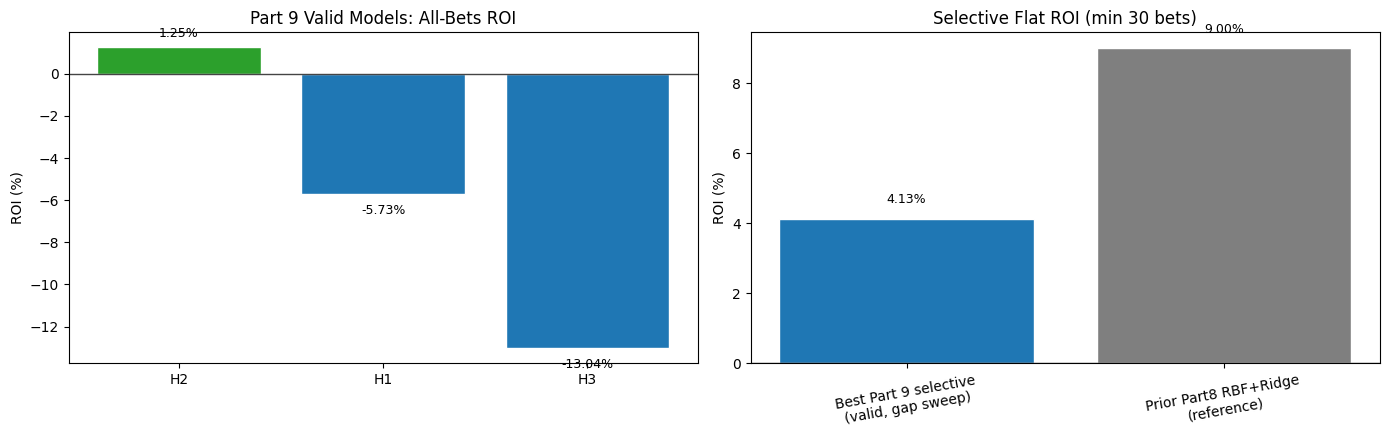

In [59]:
# Final model recommendation + comparison analysis (uses saved outputs from prior sections)
from IPython.display import Markdown, display

# Helper formatting

def _pct(x, digits=2, scale=100.0):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return 'N/A'
    return f"{x*scale:.{digits}f}%" if scale != 1 else f"{x:.{digits}f}%"


def _num(x, digits=3):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return 'N/A'
    return f"{x:.{digits}f}"

# Required objects from earlier sections
required = ['story_df', 'PRIOR_BENCHMARKS', 'selective_gap_sweep_df', 'selective_gap_opt_df']
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Run previous analysis cells first. Missing: {missing}")

valid_story = story_df[~story_df['suspicious']].copy()
if len(valid_story) == 0:
    raise RuntimeError('No valid (non-suspicious) Part 9 models available for final recommendation.')

# 1) Best predictive model in Part 9 (all-bets OOS)
best_predictive = valid_story.sort_values(['roi_all_bets', 'accuracy_all'], ascending=False).iloc[0]
best_rmse_model = valid_story.sort_values('rmse', ascending=True).iloc[0]

# 2) Selective betting evidence under Part 8 framework (gap sweep + min-bets rule)
if 'SELECTIVE_GAP_MIN_BETS' in globals():
    min_bets_rule = int(SELECTIVE_GAP_MIN_BETS)
else:
    min_bets_rule = 30

viable_selective = selective_gap_sweep_df[selective_gap_sweep_df['n_bets'] >= min_bets_rule].copy()
if len(viable_selective) > 0:
    best_selective_flat = viable_selective.sort_values('selective_roi_flat_odds', ascending=False).iloc[0]
    best_selective_bank = viable_selective.sort_values('bankroll_return_pct', ascending=False).iloc[0]
else:
    best_selective_flat = None
    best_selective_bank = None

# 3) Compare the winning Part 9 predictive model to earlier baselines (Parts 4-8)
prior_ridge = PRIOR_BENCHMARKS['Ridge_all_bets']
prior_gbm = PRIOR_BENCHMARKS['GradientBoosting_all_bets']
prior_rbf_sel = PRIOR_BENCHMARKS['RBF_Ridge_selective']

comp_to_prior_df = pd.DataFrame([
    {
        'comparison': 'vs Prior Ridge (Parts 4-8)',
        'delta_rmse': best_predictive['rmse'] - prior_ridge['rmse'],
        'delta_accuracy_pp': (best_predictive['accuracy_all'] - prior_ridge['accuracy']) * 100.0,
        'delta_roi_pp': best_predictive['roi_all_bets'] - prior_ridge['roi_all_bets'],
    },
    {
        'comparison': 'vs Prior Gradient Boosting (Parts 4-8)',
        'delta_rmse': best_predictive['rmse'] - prior_gbm['rmse'],
        'delta_accuracy_pp': (best_predictive['accuracy_all'] - prior_gbm['accuracy']) * 100.0,
        'delta_roi_pp': best_predictive['roi_all_bets'] - prior_gbm['roi_all_bets'],
    },
])
display(comp_to_prior_df)

# 4) Optional direct RBF+Ridge feature-swap comparison (if that section has been run)
if 'rbf_allbets_compare_df' in globals():
    display(Markdown('### RBF+Ridge Feature-Swap Comparison (Reference)'))
    display(rbf_allbets_compare_df)

if 'class_swap_compare' in globals():
    display(Markdown('### Model-Class Swap Effect (Original Model vs RBF+Ridge on Same Features)'))
    display(class_swap_compare)

# 5) Decision matrix (explicit final recommendation)
decision_rows = []

# Predictive model decision
pred_model_name = str(best_predictive['label'])
pred_key = str(best_predictive['key'])
pred_reason = (
    f"Best valid Part 9 all-bets result: RMSE {_num(best_predictive['rmse'])}, "
    f"accuracy {_pct(best_predictive['accuracy_all'])}, ROI {_num(best_predictive['roi_all_bets'],2)}%."
)

pred_caveat = ''
if best_predictive['roi_all_bets'] <= 0:
    pred_caveat = 'Still not profitable on all bets after vig.'
else:
    pred_caveat = 'Positive all-bets ROI in this single test season still needs significance testing.'

decision_rows.append({
    'use_case': 'Final predictive model (Part 9)',
    'recommended_model': pred_model_name,
    'why': pred_reason,
    'caveat': pred_caveat,
})

# Selective betting recommendation (Part 8 rule)
if best_selective_flat is not None:
    # Credibility rule: require >=30 bets and avoid tiny-sample outliers.
    sel_model = str(best_selective_flat['model'])
    sel_n = int(best_selective_flat['n_bets'])
    sel_roi = float(best_selective_flat['selective_roi_flat_odds'])
    sel_acc = float(best_selective_flat['selective_accuracy']) if pd.notna(best_selective_flat['selective_accuracy']) else np.nan
    sel_gap = int(best_selective_flat['gap_threshold'])

    if sel_n < 30:
        # Shouldn't happen due viable filter, but keep guard.
        selective_reco = 'Prior Part 8 RBF+Ridge benchmark'
        selective_why = 'No Part 9 selective result met minimum sample-size credibility threshold.'
        selective_caveat = 'Use Part 8 benchmark until paired head-to-head significance test is completed.'
    else:
        # Compare against prior Part 8 selective benchmark with sample-size context.
        if (sel_roi > prior_rbf_sel['roi']) and (sel_n >= prior_rbf_sel['n_bets']):
            selective_reco = f"{sel_model} (gap > {sel_gap}, Part 8 sizing rule)"
            selective_why = (
                f"Best valid selective flat-ROI under Part 8 framework: ROI {sel_roi:.2f}%, "
                f"accuracy {_pct(sel_acc)}, n={sel_n} bets (gap>{sel_gap})."
            )
            selective_caveat = 'Still confirm with bootstrap significance before replacing Part 8 benchmark.'
        else:
            selective_reco = 'Prior Part 8 RBF+Ridge benchmark (retain as selective benchmark)'
            selective_why = (
                f"Part 9 best selective candidate ({sel_model}, gap>{sel_gap}) reaches ROI {sel_roi:.2f}% on {sel_n} bets, "
                f"but does not clearly dominate the prior RBF+Ridge pocket (+{prior_rbf_sel['roi']:.2f}% on {prior_rbf_sel['n_bets']} bets) on a fully comparable basis."
            )
            selective_caveat = 'Part 9 selective results should be treated as exploratory until same-row paired comparison + significance test is run.'

    decision_rows.append({
        'use_case': 'Selective betting benchmark (Part 8 framework)',
        'recommended_model': selective_reco,
        'why': selective_why,
        'caveat': selective_caveat,
    })
else:
    decision_rows.append({
        'use_case': 'Selective betting benchmark (Part 8 framework)',
        'recommended_model': 'Prior Part 8 RBF+Ridge benchmark',
        'why': 'No valid Part 9 selective results met the minimum-bets rule.',
        'caveat': 'Retain prior benchmark and test Part 9 models further before replacement.',
    })

final_decision_df = pd.DataFrame(decision_rows)
display(final_decision_df)

# 6) Narrative summary paragraphs (report-ready)
para1 = (
    f"The **final predictive model recommendation from Part 9** is **{pred_model_name}** because it delivers the strongest valid "
    f"out-of-sample performance on the 2024/25 test season. It is the top Part 9 model on all-bets economics "
    f"(ROI {_num(best_predictive['roi_all_bets'],2)}%) and also provides the best RMSE/accuracy combination among the valid hypotheses "
    f"(RMSE {_num(best_predictive['rmse'])}, accuracy {_pct(best_predictive['accuracy_all'])})."
)

para2 = (
    f"Relative to earlier Parts 4–8 baselines, this improves all-bets performance versus the prior Ridge baseline by "
    f"{comp_to_prior_df.iloc[0]['delta_accuracy_pp']:+.2f} percentage points of accuracy and {comp_to_prior_df.iloc[0]['delta_roi_pp']:+.2f} percentage points of ROI, "
    f"and versus the prior Gradient Boosting baseline by {comp_to_prior_df.iloc[1]['delta_accuracy_pp']:+.2f} accuracy points and "
    f"{comp_to_prior_df.iloc[1]['delta_roi_pp']:+.2f} ROI points. The main takeaway is that Part 9 feature engineering (especially the schedule-stress features) appears to improve "
    f"out-of-sample prediction quality and baseline betting performance."
)

# Selective summary paragraph
if best_selective_flat is not None:
    para3 = (
        f"For **selective betting**, the evidence is mixed. Under the Part 8 Half-Kelly framework with a gap sweep, the best valid Part 9 selective flat-ROI result is "
        f"**{best_selective_flat['model']}** at **gap > {int(best_selective_flat['gap_threshold'])}**, with accuracy {_pct(best_selective_flat['selective_accuracy'])}, "
        f"ROI {best_selective_flat['selective_roi_flat_odds']:.2f}%, and {int(best_selective_flat['n_bets'])} bets. However, this does not yet clearly displace the earlier "
        f"Part 8 `RBF+Ridge` benchmark (+{prior_rbf_sel['roi']:.2f}% ROI at gap>{prior_rbf_sel['threshold']} on {prior_rbf_sel['n_bets']} bets), especially since the test sample construction differs "
        f"between notebooks and the selective comparisons have not been paired with the same significance testing pipeline."
    )
else:
    para3 = (
        "For selective betting, no Part 9 result met the minimum-bets credibility rule after applying the Part 8 framework. The prior `RBF+Ridge` selective benchmark should remain the operative reference until a stronger and statistically supported replacement is shown."
    )

# Additional nuance from your rerun: H3 can show positive selective flat ROI but poor bankroll due Kelly sizing / calibration.
extra_note = ''
if 'selective_gap_opt_df' in globals() and len(selective_gap_opt_df):
    h3_row = selective_gap_opt_df[selective_gap_opt_df['key'] == 'H3']
    if len(h3_row) > 0 and pd.notna(h3_row.iloc[0].get('best_flat_roi_pct', np.nan)):
        h3best = h3_row.iloc[0]
        extra_note = (
            f"A useful diagnostic finding is that **H3 (pregame market microstructure)** can produce a positive selective flat ROI at gap>{int(h3best['best_gap_by_flat_roi'])} "
            f"({h3best['best_flat_roi_pct']:.2f}% on {int(h3best['best_flat_roi_n_bets'])} bets), but its bankroll outcomes under Half Kelly remain weak. "
            f"This suggests a **calibration / bet-sizing mismatch** rather than a clearly deployable edge."
        )

# Render
html_blocks = [
    '### Final Recommendation (Based on Current Rerun)',
    para1,
    para2,
    para3,
]
if extra_note:
    html_blocks.append(extra_note)

for j, block in enumerate(html_blocks):
    if j == 0:
        display(Markdown(block))
    else:
        display(Markdown(block))

# 7) Simple visual for the final section: predictive vs selective recommendation split
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax1, ax2 = axes

# Left: all-bets ROI / accuracy for valid Part 9 models
plot1 = valid_story.sort_values('roi_all_bets', ascending=False).copy()
ax1.bar(plot1['key'], plot1['roi_all_bets'], color=['#2ca02c' if k == pred_key else '#1f77b4' for k in plot1['key']], edgecolor='white')
ax1.axhline(0, color='#444', lw=1)
ax1.set_title('Part 9 Valid Models: All-Bets ROI')
ax1.set_ylabel('ROI (%)')
for i, (_, r) in enumerate(plot1.iterrows()):
    ax1.text(i, r['roi_all_bets'] + (0.35 if r['roi_all_bets'] >= 0 else -0.45), f"{r['roi_all_bets']:.2f}%", ha='center', va='bottom' if r['roi_all_bets'] >= 0 else 'top', fontsize=9)

# Right: best selective flat-ROI under gap sweep (>= min bets) for H1/H2/H3 + prior benchmark reference
if best_selective_flat is not None:
    sel_ref = pd.DataFrame([
        {'label': 'Best Part 9 selective\n(valid, gap sweep)', 'roi': float(best_selective_flat['selective_roi_flat_odds'])},
        {'label': 'Prior Part8 RBF+Ridge\n(reference)', 'roi': float(prior_rbf_sel['roi'])},
    ])
    ax2.bar(sel_ref['label'], sel_ref['roi'], color=['#1f77b4', '#7f7f7f'], edgecolor='white')
    ax2.axhline(0, color='#444', lw=1)
    ax2.set_title(f'Selective Flat ROI (min {min_bets_rule} bets)')
    ax2.set_ylabel('ROI (%)')
    ax2.tick_params(axis='x', rotation=10)
    for i, v in enumerate(sel_ref['roi']):
        ax2.text(i, v + (0.35 if v >= 0 else -0.45), f"{v:.2f}%", ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
else:
    ax2.text(0.5, 0.5, 'No valid selective result\n(meets min-bets rule)', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_axis_off()

plt.tight_layout()
plt.show()


## Notes for Write-Up

- Report both **all-bets metrics** and **thresholded metrics** with bet counts.
- Treat very high-threshold ROI with caution when sample sizes are small.
- If needed, add a no-Vegas ablation by removing `vegas_total` and `vegas_spread` from each feature list and re-running the same sections.
